# LightGBM Model

This notebook aims to build LightGBM Model.

## 0. Import Libraries


In [1]:
# Data Analysis Libraries
import pandas as pd 
import numpy as np 
from IPython.display import HTML, display 
from pprint import pprint

# Data Visualization Libraries 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Machine Learning Libraries
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# Data Preparation and Evaluation Libraries
import src.data_preprocess as dp
import src.evaluation as ev

print(f"Current pandas version: {pd.__version__}")
print(f"Current LightGBM version: {lgb.__version__}")

Current pandas version: 2.0.3
Current LightGBM version: 4.6.0


## 1. Read Data


In [2]:
df1 = pd.read_csv("data/processed/creditcard_cleaned.csv")
df1.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Stratified Splitting


In [3]:
X = df1.drop(columns=['Class'])
y = df1['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
# - Check Class Distribution - 
print(y_train.value_counts() )
print('==========================')
print(y_test.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64
Class
0    56651
1       95
Name: count, dtype: int64


## 3. Feature Scaling


In [5]:
# - Scaling of Train, Validation, Test Data  - 
from sklearn.preprocessing import StandardScaler, RobustScaler
scaler = RobustScaler().set_output(transform="pandas")

# - Train StandardScaler() based on features in Train Data - 
X_train_scaled = scaler.fit_transform(X_train)

# - Apply Learning to Test Data - 
X_test_scaled = scaler.transform(X_test)

pd.set_option('display.max_columns', None)
display(X_train_scaled.describe(), X_test_scaled.describe())



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,226980.000000,226980.000000,226980.000000,2.269800e+05,2.269800e+05,226980.000000,2.269800e+05,226980.000000,2.269800e+05,2.269800e+05,226980.000000,2.269800e+05,226980.000000,2.269800e+05,2.269800e+05,226980.000000,226980.000000,2.269800e+05,2.269800e+05,2.269800e+05,2.269800e+05,2.269800e+05,2.269800e+05,226980.000000,2.269800e+05,2.269800e+05,2.269800e+05,226980.000000,226980.000000,226980.000000
mean,0.118467,-0.005974,-0.049463,-9.201113e-02,1.255679e-02,0.044015,2.349303e-01,-0.034999,-4.202809e-02,4.031268e-02,0.092410,2.092558e-02,-0.135105,9.465147e-03,-5.495478e-02,-0.039242,-0.067715,7.378956e-02,3.413561e-03,-4.556527e-03,1.819526e-01,7.178829e-02,-6.866841e-03,0.035958,-5.167418e-02,-2.380088e-02,9.178721e-02,0.001125,-0.079995,0.918890
std,0.557881,0.872721,1.176252,7.872012e-01,8.907940e-01,1.042265,1.134854e+00,1.067395,2.189368e+00,8.833613e-01,1.083991,6.783285e-01,0.971498,7.587327e-01,1.038662e+00,0.743217,0.882168,9.570856e-01,8.371572e-01,8.891543e-01,2.200688e+00,1.740203e+00,6.766285e-01,2.014884,7.621087e-01,7.798472e-01,8.495508e-01,2.412071,2.479393,3.405863
min,-0.996399,-25.288450,-51.895128,-1.768367e+01,-3.558984e+00,-24.560719,-2.219678e+01,-38.774475,-1.371258e+02,-1.080429e+01,-24.740607,-3.173772e+00,-18.298694,-4.410958e+00,-2.096634e+01,-3.697117,-14.336465,-2.848973e+01,-9.495503e+00,-7.888350e+00,-6.833706e+01,-8.385150e+01,-1.021956e+01,-144.253529,-3.620168e+00,-1.541592e+01,-4.505273e+00,-139.366693,-89.223071,-0.305987
25%,-0.359179,-0.418701,-0.474124,-5.565134e-01,-5.200782e-01,-0.488053,-4.226226e-01,-0.527684,-4.322513e-01,-4.775868e-01,-0.446674,-4.862148e-01,-0.531611,-4.851090e-01,-5.182132e-01,-0.512350,-0.540332,-4.750870e-01,-4.965198e-01,-5.028997e-01,-4.328936e-01,-4.804289e-01,-5.128786e-01,-0.486354,-4.980661e-01,-4.991125e-01,-4.850961e-01,-0.444802,-0.487763,-0.227134
50%,0.000000,0.000000,0.000000,7.248908e-18,-1.090131e-18,0.000000,-2.380163e-17,0.000000,-3.247948e-18,-2.801138e-18,0.000000,2.310706e-18,0.000000,-6.623798e-19,-3.776205e-18,0.000000,0.000000,7.877406e-18,1.084202e-19,4.739149e-19,-1.005269e-17,4.179578e-18,-4.050935e-19,0.000000,4.364549e-18,-2.593403e-18,6.122354e-18,0.000000,0.000000,0.000000
75%,0.640821,0.581299,0.525876,4.434866e-01,4.799218e-01,0.511947,5.773774e-01,0.472316,5.677487e-01,5.224132e-01,0.553326,5.137852e-01,0.468389,5.148910e-01,4.817868e-01,0.487650,0.459668,5.249130e-01,5.034802e-01,4.971003e-01,5.671064e-01,5.195711e-01,4.871214e-01,0.513646,5.019339e-01,5.008875e-01,5.149039e-01,0.555198,0.512237,0.772866
max,1.033522,1.092001,15.682657,4.807100e+00,1.062278e+01,26.718231,1.858179e+01,30.471631,3.741801e+01,1.263434e+01,24.078235,8.024285e+00,7.548203,3.497499e+00,1.140431e+01,4.695650,7.058798,1.057889e+01,5.041094e+00,6.083943e+00,1.144026e+02,6.561204e+01,9.803975e+00,72.582873,5.000781e+00,1.121771e+01,6.298669e+00,75.039553,257.540705,272.096037


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000
mean,0.113231,-0.003980,-0.044423,-0.093364,0.009599,0.032082,0.238452,-0.033571,-0.048015,0.045509,0.096142,0.021332,-0.138831,0.014336,-0.044714,-0.038634,-0.068547,0.078304,-0.000376,-0.009845,0.175263,0.054453,-0.007278,0.042859,-0.050590,-0.027381,0.090403,0.003642,-0.095226,0.924819
std,0.557445,0.874368,1.165828,0.790887,0.882038,1.107183,1.170976,1.184582,2.278849,0.889145,1.100038,0.678528,0.982750,0.764100,1.027296,0.745676,0.882343,0.953627,0.837333,0.887724,2.348528,1.760020,0.677495,1.982522,0.760925,0.776761,0.855430,2.567627,2.564886,3.715792
min,-0.996376,-16.840672,-27.358936,-25.332104,-3.391221,-87.152273,-18.568409,-29.598114,-94.945916,-8.711826,-21.064987,-2.716157,-18.425977,-2.903112,-19.699068,-3.296047,-13.502457,-24.570406,-9.087740,-5.053059,-157.727687,-55.080637,-6.644623,-118.035448,-3.532122,-10.059626,-2.936521,-61.118690,-117.531159,-0.305987
25%,-0.361326,-0.418996,-0.471600,-0.561773,-0.523038,-0.489962,-0.423449,-0.527689,-0.434304,-0.477310,-0.444916,-0.486816,-0.536814,-0.482081,-0.509679,-0.513796,-0.541132,-0.473709,-0.497599,-0.507988,-0.431094,-0.483419,-0.517839,-0.475431,-0.495680,-0.497567,-0.486766,-0.447783,-0.494365,-0.229906
50%,-0.004065,0.004787,0.000498,0.004239,-0.000770,-0.004294,0.002639,0.000059,-0.003020,0.003104,0.002172,-0.002586,0.004742,0.000499,0.007718,0.000738,-0.007238,-0.001444,-0.005386,-0.007891,-0.002453,-0.009434,-0.003070,0.004725,-0.000633,0.000893,-0.004452,-0.000872,-0.007033,-0.006860
75%,0.636953,0.582886,0.522292,0.442669,0.474417,0.500292,0.574122,0.465906,0.569995,0.529935,0.550162,0.511724,0.471186,0.521407,0.485348,0.491106,0.458927,0.535109,0.501426,0.489544,0.562270,0.511902,0.484464,0.507367,0.499638,0.497589,0.517223,0.549261,0.494575,0.754123
max,1.033452,1.081056,11.860807,1.956759,9.635044,25.269252,63.094880,107.211413,29.529848,8.434062,13.876111,7.497928,4.342747,5.449921,8.387040,7.176662,17.414621,10.526140,4.054706,6.105645,70.108303,48.411126,7.720137,61.230126,5.715579,7.164033,6.203194,195.216185,120.680145,355.724501


In [6]:
# - Check Scaling Validity Manually - 
dp.check_scaling_validity(X_train_scaled)
dp.check_scaling_validity(X_test_scaled)

✅ Feature means after scaling:
 Time      0.118467
V1       -0.005974
V2       -0.049463
V3       -0.092011
V4        0.012557
V5        0.044015
V6        0.234930
V7       -0.034999
V8       -0.042028
V9        0.040313
V10       0.092410
V11       0.020926
V12      -0.135105
V13       0.009465
V14      -0.054955
V15      -0.039242
V16      -0.067715
V17       0.073790
V18       0.003414
V19      -0.004557
V20       0.181953
V21       0.071788
V22      -0.006867
V23       0.035958
V24      -0.051674
V25      -0.023801
V26       0.091787
V27       0.001125
V28      -0.079995
Amount    0.918890
dtype: float64
-----------------------------------

✅ Feature std devs after scaling:
 Time      0.557881
V1        0.872721
V2        1.176252
V3        0.787201
V4        0.890794
V5        1.042265
V6        1.134854
V7        1.067395
V8        2.189368
V9        0.883361
V10       1.083991
V11       0.678329
V12       0.971498
V13       0.758733
V14       1.038662
V15       0.743217
V16    

## 4. LightGBM Model (Stratified K-Fold Validation)


### Import ML Libraries


In [7]:
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline  # Changed from sklearn.pipeline for SMOTE compatibility
from sklearn.metrics import log_loss
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

### Instantiate Models & Hyperparameters


In [8]:
# - Define Hyperparameters - 
lightgbm_params={
      'objective': 'binary', # objective function: log loss 
      'max_depth': 5, 
      'n_jobs': -1,  # use all CPU Cores
      'random_state': 42, 
      'device_type': 'cpu', # can adjust to GPU
      'verbose': -1, 
      'force_col_wise': True
   }

# - Custom Scorer for F2 Score (Prefer Recall over Precision) -
from sklearn.metrics import make_scorer, fbeta_score
f2_scorer = make_scorer(fbeta_score, beta=2) # default: 1 as pos class 


# - Instantiate Models - 
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('lgbm', LGBMClassifier(**lightgbm_params))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Define CV Logging Class


In [9]:
from wandb.integration.lightgbm import wandb_callback

import wandb
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report

class LightGBMCrossValidator:
    """
    A modularized class to handle cross-validation training with WandB logging for LightGBM models.
    """
    
    def __init__(self, pipeline, cv_splitter, project_name="fraud-detection", 
                 experiment_prefix="lightgbm_smote", group_name=None):
        """
        Initialize the cross-validator.
        
        Parameters:
        -----------
        pipeline : Pipeline
            The sklearn/imblearn pipeline containing SMOTE and LGBMClassifier
        cv_splitter : cross-validation splitter
            e.g., StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        project_name : str
            WandB project name
        experiment_prefix : str
            Prefix for the experiment group name
        group_name : str, optional
            Custom group name for WandB. If None, will auto-generate with prefix and ID
        """
        self.pipeline = pipeline
        self.cv_splitter = cv_splitter
        self.project_name = project_name
        self.experiment_prefix = experiment_prefix
        self.group_name = group_name
        self.fold_results = []
        self.group_id = None
        self.final_group_name = None
    
    def _setup_wandb_group(self):
        """Setup WandB group name for the experiment."""
        if self.group_name is None:
            self.group_id = wandb.util.generate_id()
            self.final_group_name = f"{self.experiment_prefix}_{self.group_id}"
        else:
            self.final_group_name = self.group_name
    
    def _train_fold(self, X_train_fold, y_train_fold, X_val_fold, y_val_fold):
        """
        Train the pipeline on a single fold.
        
        Parameters:
        -----------
        X_train_fold, y_train_fold : Training data for this fold
        X_val_fold, y_val_fold : Validation data for this fold
        
        Returns:
        --------
        None (modifies self.pipeline in place)
        """
        self.pipeline.fit(
            X_train_fold, y_train_fold,
            lgbm__eval_set=[(X_train_fold, y_train_fold), (X_val_fold, y_val_fold)],
            lgbm__eval_names=['train', 'val'],
            lgbm__eval_metric=['binary_logloss', 'auc', 'average_precision'],
            lgbm__callbacks=[wandb_callback()]
        )
    
    def _calculate_metrics(self, X_train_fold, y_train_fold, X_val_fold, y_val_fold):
        """
        Calculate metrics for both training and validation sets.
        
        Parameters:
        -----------
        X_train_fold, y_train_fold : Training data for this fold
        X_val_fold, y_val_fold : Validation data for this fold
        
        Returns:
        --------
        dict : Combined training and validation metrics
        """
        # Validation predictions
        y_pred_val = self.pipeline.predict(X_val_fold)
        y_probas_val_full = self.pipeline.predict_proba(X_val_fold)
        y_pred_proba_val = y_probas_val_full[:, 1]
        
        # Training predictions
        y_pred_train = self.pipeline.predict(X_train_fold)
        y_probas_train_full = self.pipeline.predict_proba(X_train_fold)
        y_pred_proba_train = y_probas_train_full[:, 1]

        # Validation metrics
        val_metrics = {
            "val_f2_score": fbeta_score(y_val_fold, y_pred_val, beta=2),
            "val_precision": precision_score(y_val_fold, y_pred_val),
            "val_recall": recall_score(y_val_fold, y_pred_val),
            "val_f1_score": f1_score(y_val_fold, y_pred_val),
            "val_roc_auc": roc_auc_score(y_val_fold, y_pred_proba_val), 
            'val_pr_auc': average_precision_score(y_val_fold, y_pred_proba_val),
            "val_log_loss": log_loss(y_val_fold, y_pred_proba_val)
        }
        
        # Training metrics
        train_metrics = {
            "train_f2_score": fbeta_score(y_train_fold, y_pred_train, beta=2),
            "train_precision": precision_score(y_train_fold, y_pred_train),
            "train_recall": recall_score(y_train_fold, y_pred_train),
            "train_f1_score": f1_score(y_train_fold, y_pred_train),
            "train_roc_auc": roc_auc_score(y_train_fold, y_pred_proba_train), 
            'train_pr_auc': average_precision_score(y_train_fold, y_pred_proba_train),
            "train_log_loss": log_loss(y_train_fold, y_pred_proba_train)
        }
        
        # Store predictions for plotting
        self.y_val_fold = y_val_fold
        self.y_pred_val = y_pred_val
        self.y_probas_val_full = y_probas_val_full
        
        return {**val_metrics, **train_metrics}
    
    def _create_plots(self, run):
        """
        Create and log all plots to WandB.
        
        Parameters:
        -----------
        run : WandB run object
        """
        # PR and ROC curves
        run.log({"pr": wandb.plot.pr_curve(self.y_val_fold, self.y_probas_val_full)})
        run.log({"roc": wandb.plot.roc_curve(self.y_val_fold, self.y_probas_val_full)})

        # Confusion matrix
        cm = wandb.plot.confusion_matrix(
            probs=self.y_probas_val_full, 
            y_true=self.y_val_fold.to_numpy(), 
            class_names=['Non-Fraud', 'Fraud']
        )
        run.log({"confusion_matrix": cm})
    
    def _create_classification_report(self, run):
        """
        Create and log classification report table.
        
        Parameters:
        -----------
        run : WandB run object
        """
        class_names = ['Non-Fraud', 'Fraud']
        report_columns = ["Class", "Precision", "Recall", "F1-score", "Support"]
        class_report = classification_report(
            y_true=self.y_val_fold, 
            y_pred=self.y_pred_val, 
            target_names=class_names
        ).splitlines()
        
        report_table = []
        for line in class_report[2:(len(class_names)+2)]:
            report_table.append(line.split())
        
        run.log({
            "classification_report": wandb.Table(data=report_table, columns=report_columns)
        })
    
    def _create_feature_importance_plot(self, run, X_train_fold):
        """
        Create and log feature importance plot.
        
        Parameters:
        -----------
        run : WandB run object
        X_train_fold : Training features for column names
        """
        feature_importance = lgb.plot_importance(
            booster=self.pipeline.named_steps['lgbm'], 
            importance_type='gain', 
            title='Feature Importance', 
            figsize=(10, 6)
        )
        run.log({"feature_importance": wandb.Image(feature_importance)})
        plt.close()
    
    def _initialize_wandb_run(self, fold):
        """
        Initialize WandB run for a specific fold.
        
        Parameters:
        -----------
        fold : int, current fold number
        
        Returns:
        --------
        WandB run object
        """
        return wandb.init(
            project=self.project_name,
            group=self.final_group_name,
            job_type=f"fold_{fold}",
            config={
                **self.pipeline.named_steps['lgbm'].get_params(),
                "fold": fold,
                "n_folds": self.cv_splitter.get_n_splits(),
                "pipeline": "SMOTE + LGBMClassifier"
            },
            name=f"fold_{fold+1}", 
            tags=["train-validation-fold"], 
            reinit=True,
            settings=wandb.Settings(_disable_stats=True, _disable_meta=True)
        )
    
    def run_cross_validation(self, X_train_scaled, y_train):
        """
        Run the complete cross-validation training loop with WandB logging.
        
        Parameters:
        -----------
        X_train_scaled : DataFrame
            Scaled training features
        y_train : Series
            Training labels
            
        Returns:
        --------
        list : fold_results containing metrics for each fold
        """
        # Setup WandB group
        self._setup_wandb_group()
        
        # Reset results
        self.fold_results = []
        
        # Cross-validation loop
        for fold, (train_idx, test_idx) in enumerate(self.cv_splitter.split(X_train_scaled, y_train)):
            
            # Initialize WandB run for this fold
            run = self._initialize_wandb_run(fold)
            
            # Split data for this fold
            X_train_fold = X_train_scaled.iloc[train_idx]
            X_val_fold = X_train_scaled.iloc[test_idx]
            y_train_fold = y_train.iloc[train_idx]
            y_val_fold = y_train.iloc[test_idx]

            # 1. TRAINING
            self._train_fold(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
            
            # 2. CALCULATE METRICS
            fold_metrics = self._calculate_metrics(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
            wandb.log(fold_metrics)
            self.fold_results.append(fold_metrics)
            
            # 3. CREATE PLOTS
            self._create_plots(run)
            self._create_classification_report(run)
            self._create_feature_importance_plot(run, X_train_fold)
            
            # Finish run
            run.finish()
        
        return self.fold_results
    
    def get_average_metrics(self):
        """
        Calculate average metrics across all folds.
        
        Returns:
        --------
        dict : Average metrics across folds
        """
        if not self.fold_results:
            raise ValueError("No fold results available. Run cross_validation first.")
        
        avg_metrics = {}
        metric_names = self.fold_results[0].keys()
        
        for metric in metric_names:
            values = [fold[metric] for fold in self.fold_results]
            avg_metrics[f"mean_{metric}"] = np.mean(values)
            avg_metrics[f"std_{metric}"] = np.std(values)
        
        return avg_metrics
    
    def create_summary_run(self, additional_config=None):
        """
        Create a summary WandB run with cross-validation statistics.
        
        Parameters:
        -----------
        additional_config : dict, optional
            Additional configuration to log (e.g., hyperparameters)
            
        Returns:
        --------
        None
        """
        if not self.fold_results:
            raise ValueError("No fold results available. Run cross_validation first.")
        
        # Base config
        config = {
            "pipeline": "SMOTE + LGBMClassifier",
            "n_folds": self.cv_splitter.get_n_splits()
        }
        
        # Add pipeline parameters
        config.update(self.pipeline.named_steps['lgbm'].get_params())
        
        # Add any additional config
        if additional_config:
            config.update(additional_config)
        
        # Initialize summary run
        summary_run = wandb.init(
            project=self.project_name,
            group=self.final_group_name,
            job_type="summary",
            config=config,
            name="cross_validation_summary",
            tags=["summary"],
            settings=wandb.Settings(_disable_stats=True, _disable_meta=True)
        )
        
        # Log mean, std, min, max across all folds for each metric
        metric_names = self.fold_results[0].keys()
        for metric in metric_names:
            values = [result[metric] for result in self.fold_results]
            summary_run.log({
                f"cv_mean_{metric}": np.mean(values),
                f"cv_std_{metric}": np.std(values),
            })
        
        # Create comparison table for train vs validation metrics
        comparison_df = self._create_metrics_comparison_table()
        
        # Log as WandB table
        summary_run.log({
            "metrics_comparison": wandb.Table(dataframe=comparison_df)
        })
        
        summary_run.finish()
        
        # Print summary
        self._print_summary(comparison_df)
    
    def _create_metrics_comparison_table(self):
        """
        Create a comparison table for train vs validation metrics.
        
        Returns:
        --------
        pd.DataFrame : Comparison table
        """
        import pandas as pd
        
        metric_names = self.fold_results[0].keys()
        train_metrics = [m for m in metric_names if m.startswith('train_')]
        val_metrics = [m for m in metric_names if m.startswith('val_')]
        
        # Extract base metric names (without train_/val_ prefix)
        base_metrics = list(set([m.replace('train_', '').replace('val_', '') for m in metric_names]))
        
        comparison_data = []
        for base_metric in sorted(base_metrics):
            train_metric = f"train_{base_metric}"
            val_metric = f"val_{base_metric}"
            
            if train_metric in metric_names and val_metric in metric_names:
                train_values = [result[train_metric] for result in self.fold_results]
                val_values = [result[val_metric] for result in self.fold_results]
                
                comparison_data.append({
                    'metric': base_metric,
                    'train_mean': np.mean(train_values),
                    'train_std': np.std(train_values),
                    'val_mean': np.mean(val_values),
                    'val_std': np.std(val_values),
                    'overfitting_gap': np.mean(train_values) - np.mean(val_values)
                })
        
        return pd.DataFrame(comparison_data)
    
    def _print_summary(self, comparison_df):
        """
        Print summary of logged results.
        
        Parameters:
        -----------
        comparison_df : pd.DataFrame
            Metrics comparison table
        """
        train_metrics = [m for m in self.fold_results[0].keys() if m.startswith('train_')]
        val_metrics = [m for m in self.fold_results[0].keys() if m.startswith('val_')]
        
        print(f"✅ Summary run completed for group: {self.final_group_name}")
        print(f"✅ Logged {len(train_metrics)} training metrics and {len(val_metrics)} validation metrics")
        print(f"✅ Created metrics comparison table with {len(comparison_df)} metrics")
        
        print("\n📊 Train vs Validation Metrics Comparison:")
        print("=" * 60)
        print(comparison_df.round(4).to_string(index=False))

/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or

In [10]:
# - Cross Validation & Logging - 
cv_trainer = LightGBMCrossValidator(
    pipeline=pipeline, 
    cv_splitter=skf,
    project_name="Fraud Detection",
    experiment_prefix="lightgbm_smote",
    group_name='Train-Validation CV'
)

# Run the cross-validation
fold_results = cv_trainer.run_cross_validation(X_train_scaled, y_train)

wandb: Currently logged in as: wlunlun1212 (wlunlun1212-singapore-management-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


iteration,▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train_auc,▁▆▆▆▆▆▇▇▇▇▇▇▇▇██████████████████████████
train_average_precision,▁▂▂▄▄▆▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████████████
train_binary_logloss,█▇▆▅▄▄▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_f1_score,▁
train_f2_score,▁
train_log_loss,▁
train_pr_auc,▁
train_precision,▁
train_recall,▁
+11,...


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


iteration,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train_auc,▁▃▃▃▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████████
train_average_precision,▁▂▂▃▃▅▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇████████
train_binary_logloss,█▇▆▅▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_f1_score,▁
train_f2_score,▁
train_log_loss,▁
train_pr_auc,▁
train_precision,▁
train_recall,▁
+11,...


...

iteration,▁▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇███
train_auc,▁▃▄▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████
train_average_precision,▁▂▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████
train_binary_logloss,█▇▆▅▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_f1_score,▁
train_f2_score,▁
train_log_loss,▁
train_pr_auc,▁
train_precision,▁
train_recall,▁
+11,...


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


iteration,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train_auc,▁▅▇▇▇▇▇▇▇▇▇█████████████████████████████
train_average_precision,▁▂▄▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇█████████████
train_binary_logloss,█▇▆▅▅▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_f1_score,▁
train_f2_score,▁
train_log_loss,▁
train_pr_auc,▁
train_precision,▁
train_recall,▁
+11,...


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


iteration,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇████
train_auc,▁▂▃▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████████████████
train_average_precision,▁▁▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇████████████
train_binary_logloss,█▇▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_f1_score,▁
train_f2_score,▁
train_log_loss,▁
train_pr_auc,▁
train_precision,▁
train_recall,▁
+11,...


In [11]:
# Print average metrics
avg_metrics = cv_trainer.get_average_metrics()
print("Average Cross-Validation Metrics:")
print("==================================")
for metric, value in avg_metrics.items():
    print(f"{metric}: {value:.4f}")

# Create the summary run with additional hyperparameters
cv_trainer.create_summary_run(additional_config=lightgbm_params)

Average Cross-Validation Metrics:
mean_val_f2_score: 0.6336
std_val_f2_score: 0.0296
mean_val_precision: 0.3156
std_val_precision: 0.0253
mean_val_recall: 0.8492
std_val_recall: 0.0381
mean_val_f1_score: 0.4596
std_val_f1_score: 0.0286
mean_val_roc_auc: 0.9748
std_val_roc_auc: 0.0094
mean_val_pr_auc: 0.8076
std_val_pr_auc: 0.0321
mean_val_log_loss: 0.0179
std_val_log_loss: 0.0018
mean_train_f2_score: 0.7584
std_train_f2_score: 0.0174
mean_train_precision: 0.3865
std_train_precision: 0.0220
mean_train_recall: 1.0000
std_train_recall: 0.0000
mean_train_f1_score: 0.5571
std_train_f1_score: 0.0231
mean_train_roc_auc: 1.0000
std_train_roc_auc: 0.0000
mean_train_pr_auc: 0.9841
std_train_pr_auc: 0.0055
mean_train_log_loss: 0.0156
std_train_log_loss: 0.0018


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


cv_mean_train_f1_score,▁
cv_mean_train_f2_score,▁
cv_mean_train_log_loss,▁
cv_mean_train_pr_auc,▁
cv_mean_train_precision,▁
cv_mean_train_recall,▁
cv_mean_train_roc_auc,▁
cv_mean_val_f1_score,▁
cv_mean_val_f2_score,▁
cv_mean_val_log_loss,▁
+18,...


✅ Summary run completed for group: Train-Validation CV
✅ Logged 7 training metrics and 7 validation metrics
✅ Created metrics comparison table with 7 metrics

📊 Train vs Validation Metrics Comparison:
   metric  train_mean  train_std  val_mean  val_std  overfitting_gap
 f1_score      0.5571     0.0231    0.4596   0.0286           0.0975
 f2_score      0.7584     0.0174    0.6336   0.0296           0.1248
 log_loss      0.0156     0.0018    0.0179   0.0018          -0.0022
   pr_auc      0.9841     0.0055    0.8076   0.0321           0.1764
precision      0.3865     0.0220    0.3156   0.0253           0.0708
   recall      1.0000     0.0000    0.8492   0.0381           0.1508
  roc_auc      1.0000     0.0000    0.9748   0.0094           0.0252


## 5. Baseline LightGBM Model Diagnostics
|F2 Score Comparison|Train-Val Mean & STD Comparison| Precision-Recall Curve |
|:-:|:-:|:-:|
|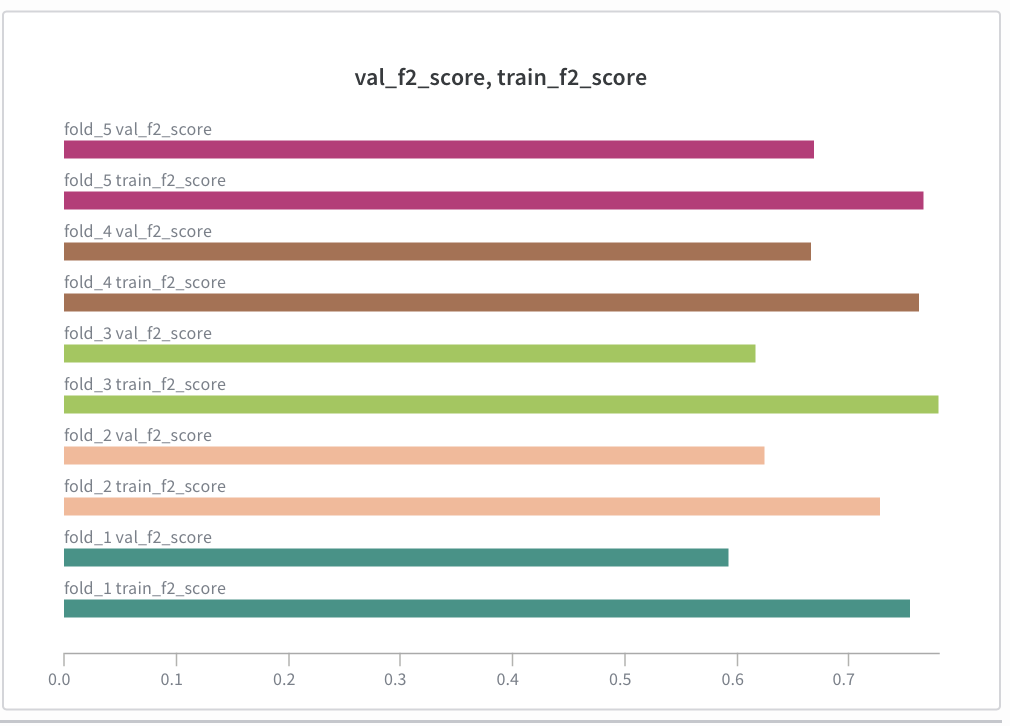 |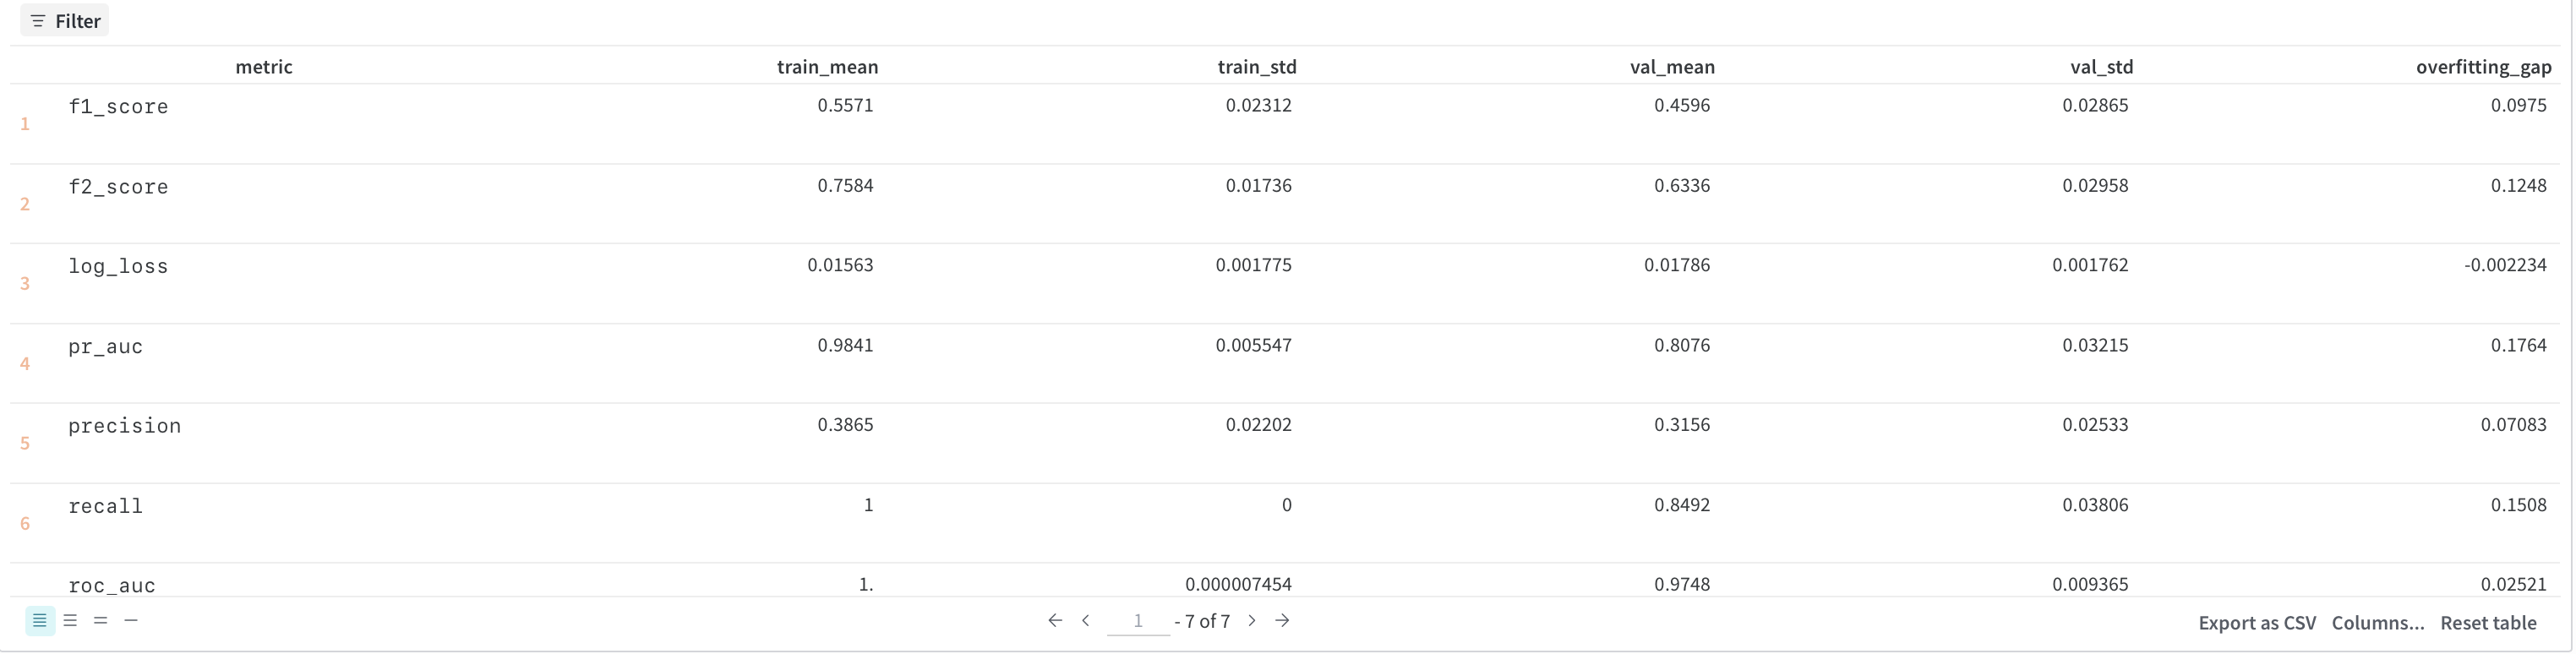| 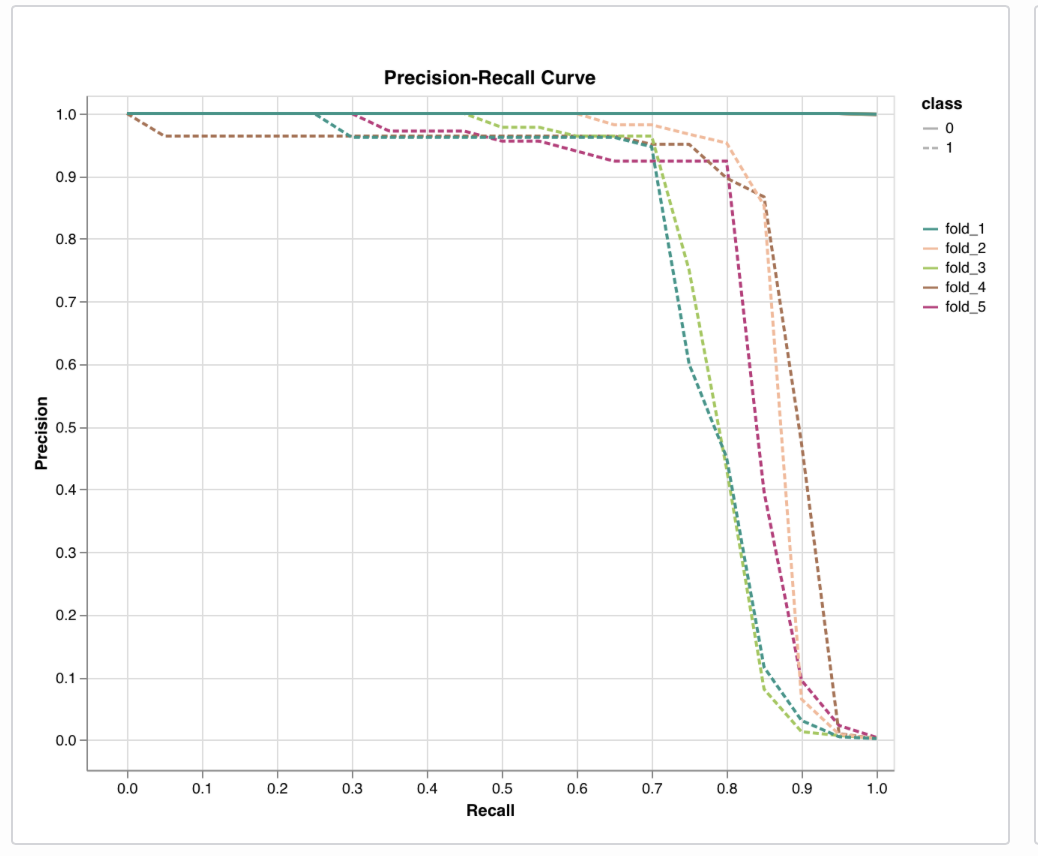 |

- **Overfitting**: Confirmed (large gap between train and validation across metrics)
- **F2 Score problem**: F2 score is 0.57, which isn't optimized for fraud detection (we want to capture many fraudulent transactions, without raising too many false alarms). Current model raises too many false alarms, in order to capture more fraudulent transactions 
- **F1 Score drop**: Suffers on validation folds, mostly due to substantial drop in Recall from 1.0 to 0.846 (Model misses more TPs on validation set) (**Overfitting**)
- **Threshold Issue**: PR curve is curved far right, I have high recall but low precision (**Classifier threshold is too low**) -> To be tuned after hyperparameter tuning 


## 6. Hyperparameter Tuning (WandB Sweep)

### Define Sweep Configuration & Training Function 

In [12]:
import math

sweep_config = {
    "method": "bayes",  # or "random" / "grid"
    "metric": {
        "goal": "maximize",
        "name": "val_f2_score"  # or whatever metric you want to optimize
    },
    "parameters": {
        # Learning parameters
        "learning_rate": {
            "distribution": "log_uniform_values",
            "min": 0.001,
            "max": 0.3
        },
        "num_iterations": {
            "distribution": "int_uniform",
            "min": 100,
            "max": 1000
        },

        # Tree structure
        "max_depth": {
            "distribution": "int_uniform",
            "min": 3,
            "max": 12
        },
        "num_leaves": {
            "distribution": "int_uniform",
            "min": 10,
            "max": 300
        },
        "min_data_in_leaf": {
            "distribution": "int_uniform",
            "min": 5,
            "max": 100
        },
        "max_bin": {
            "distribution": "int_uniform",
            "min": 63,
            "max": 512
        },

        # Regularization
        "lambda_l1": {
            "distribution": "uniform",
            "min": 0.0,
            "max": 10.0
        },
        "lambda_l2": {
            "distribution": "uniform",
            "min": 0.0,
            "max": 10.0
        },
        "min_gain_to_split": {
            "distribution": "uniform",
            "min": 0.0,
            "max": 5.0
        },
        "path_smooth": {
            "distribution": "uniform",
            "min": 0.0,
            "max": 100.0
        },

        # Sampling
        "feature_fraction": {
            "distribution": "uniform",
            "min": 0.4,
            "max": 1.0
        },
        "bagging_fraction": {
            "distribution": "uniform",
            "min": 0.4,
            "max": 1.0
        },
        "bagging_freq": {
            "distribution": "int_uniform",
            "min": 0,
            "max": 7
        },

        # Boosting type
        "boosting_type": {
            "values": ["gbdt", "dart"]
        }
    }
}


In [13]:
pprint(sweep_config)

{'method': 'bayes',
 'metric': {'goal': 'maximize', 'name': 'val_f2_score'},
 'parameters': {'bagging_fraction': {'distribution': 'uniform',
                                     'max': 1.0,
                                     'min': 0.4},
                'bagging_freq': {'distribution': 'int_uniform',
                                 'max': 7,
                                 'min': 0},
                'boosting_type': {'values': ['gbdt', 'dart']},
                'feature_fraction': {'distribution': 'uniform',
                                     'max': 1.0,
                                     'min': 0.4},
                'lambda_l1': {'distribution': 'uniform',
                              'max': 10.0,
                              'min': 0.0},
                'lambda_l2': {'distribution': 'uniform',
                              'max': 10.0,
                              'min': 0.0},
                'learning_rate': {'distribution': 'log_uniform_values',
                         

### Define Training Function

In [14]:
def training_function():
    """
    Training function for WandB sweep optimization.
    Creates a new pipeline with sweep hyperparameters and runs cross-validation.
    """
    import os
    import sys
    
    # Comprehensive environment setup to disable all Jupyter features
    os.environ["WANDB_SILENT"] = "true"
    os.environ["WANDB_CONSOLE"] = "off"
    os.environ["WANDB_DISABLE_CODE"] = "true"
    os.environ["WANDB_MODE"] = "online"
    os.environ["WANDB_NOTEBOOK_NAME"] = ""
    os.environ["JUPYTER_ENABLE_LAB"] = "false"
    
    # Patch sys.modules to prevent widget imports
    original_modules = {}
    widget_modules = ['ipywidgets', 'ipywidgets.widgets', 'IPython.display', 'jupyter_widgets']
    
    for module_name in widget_modules:
        if module_name in sys.modules:
            original_modules[module_name] = sys.modules[module_name]
            sys.modules[module_name] = None
    
    try:
        # Monkey patch the environment detection
        original_in_notebook = getattr(wandb.sdk.lib.ipython, '_in_notebook', None)
        if hasattr(wandb.sdk.lib.ipython, '_in_notebook'):
            wandb.sdk.lib.ipython._in_notebook = lambda: False
            
        # Initialize WandB run without any Jupyter features
        run = wandb.init(
            mode="online",
            settings=wandb.Settings(
                console="off",
                _disable_stats=True,
                _disable_meta=True
            )
        )
        config = wandb.config
        
        # Extract hyperparameters from config and merge with base lightgbm_params
        sweep_params = {
            'objective': 'binary',
            'random_state': 42,
            'n_jobs': -1,
            'device_type': 'cpu',
            'verbose': -1,
            'force_col_wise': True
        }
        
        # Add sweep hyperparameters
        for key, value in config.items():
            sweep_params[key] = value
        
        # Create new pipeline with sweep hyperparameters
        sweep_pipeline = Pipeline([
            ('smote', SMOTE(random_state=42, k_neighbors=5)),
            ('lgbm', LGBMClassifier(**sweep_params))
        ])
        
        # Simplified cross-validation without the full LightGBMCrossValidator class
        fold_results = []
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
            X_train_fold = X_train_scaled.iloc[train_idx]
            X_val_fold = X_train_scaled.iloc[val_idx]
            y_train_fold = y_train.iloc[train_idx]
            y_val_fold = y_train.iloc[val_idx]
            
            # Train the pipeline
            sweep_pipeline.fit(X_train_fold, y_train_fold)
            
            # Predict
            y_pred_val = sweep_pipeline.predict(X_val_fold)
            y_pred_proba_val = sweep_pipeline.predict_proba(X_val_fold)[:, 1]
            
            # Calculate metrics
            fold_metrics = {
                "val_f2_score": fbeta_score(y_val_fold, y_pred_val, beta=2),
                "val_precision": precision_score(y_val_fold, y_pred_val),
                "val_recall": recall_score(y_val_fold, y_pred_val),
                "val_roc_auc": roc_auc_score(y_val_fold, y_pred_proba_val)
            }
            fold_results.append(fold_metrics)
        
        # Calculate and log average metrics
        avg_metrics = {}
        for metric in fold_results[0].keys():
            values = [fold[metric] for fold in fold_results]
            avg_metrics[f"mean_{metric}"] = np.mean(values)
            avg_metrics[f"std_{metric}"] = np.std(values)
        
        wandb.log({
            "val_f2_score": avg_metrics["mean_val_f2_score"],
            "val_f2_score_std": avg_metrics["std_val_f2_score"],
            "val_recall": avg_metrics["mean_val_recall"],
            "val_precision": avg_metrics["mean_val_precision"],
            "val_roc_auc": avg_metrics["mean_val_roc_auc"]
        })
        
        run.finish()
        
    finally:
        # Restore original modules
        for module_name, original_module in original_modules.items():
            if original_module is not None:
                sys.modules[module_name] = original_module
        
        # Restore original notebook detection
        if original_in_notebook is not None:
            wandb.sdk.lib.ipython._in_notebook = original_in_notebook

In [15]:
# Alternative approach: Create a standalone sweep script
sweep_script_content = '''
import os
import sys
import pandas as pd
import numpy as np
import wandb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.metrics import fbeta_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, log_loss

# Add the project root to the path
sys.path.append('/Users/lunlun/Downloads/Github/Fraud-Detection-ML')

def load_and_prepare_data():
    """Load and prepare the data for training"""
    df1 = pd.read_csv("/Users/lunlun/Downloads/Github/Fraud-Detection-ML/data/processed/creditcard_cleaned.csv")
    X = df1.drop(columns=['Class'])
    y = df1['Class']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Scale the data
    scaler = RobustScaler().set_output(transform="pandas")
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test

def training_function():
    """Training function for WandB sweep optimization."""
    # Initialize WandB run
    run = wandb.init()
    config = wandb.config
    
    # Load data
    X_train_scaled, X_test_scaled, y_train, y_test = load_and_prepare_data()
    
    # Extract hyperparameters from config
    sweep_params = {
        'objective': 'binary',
        'random_state': 42,
        'n_jobs': -1,
        'device_type': 'cpu',
        'verbose': -1,
        'force_col_wise': True
    }
    
    # Add sweep hyperparameters
    for key, value in config.items():
        sweep_params[key] = value
    
    # Create pipeline
    pipeline = Pipeline([
        ('smote', SMOTE(random_state=42, k_neighbors=5)),
        ('lgbm', LGBMClassifier(**sweep_params))
    ])
    
    # Cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
        X_train_fold = X_train_scaled.iloc[train_idx]
        X_val_fold = X_train_scaled.iloc[val_idx]
        y_train_fold = y_train.iloc[train_idx]
        y_val_fold = y_train.iloc[val_idx]
        
        # Train the pipeline
        pipeline.fit(X_train_fold, y_train_fold)
        
        # Predict
        y_pred_val = pipeline.predict(X_val_fold)
        y_pred_proba_val = pipeline.predict_proba(X_val_fold)[:, 1]
        
        # Calculate metrics
        f2_score = fbeta_score(y_val_fold, y_pred_val, beta=2)
        precision = precision_score(y_val_fold, y_pred_val)
        recall = recall_score(y_val_fold, y_pred_val)
        roc_auc = roc_auc_score(y_val_fold, y_pred_proba_val)
        
        fold_scores.append({
            'f2_score': f2_score,
            'precision': precision,
            'recall': recall,
            'roc_auc': roc_auc
        })
    
    # Calculate average metrics
    avg_f2 = np.mean([score['f2_score'] for score in fold_scores])
    avg_precision = np.mean([score['precision'] for score in fold_scores])
    avg_recall = np.mean([score['recall'] for score in fold_scores])
    avg_roc_auc = np.mean([score['roc_auc'] for score in fold_scores])
    
    # Log metrics
    wandb.log({
        'val_f2_score': avg_f2,
        'val_precision': avg_precision,
        'val_recall': avg_recall,
        'val_roc_auc': avg_roc_auc
    })
    
    run.finish()

if __name__ == "__main__":
    # Sweep configuration
    sweep_config = {
        "method": "bayes",
        "metric": {
            "goal": "maximize",
            "name": "val_f2_score"
        },
        "parameters": {
            "learning_rate": {
                "distribution": "log_uniform_values",
                "min": 0.001,
                "max": 0.3
            },
            "num_iterations": {
                "distribution": "int_uniform",
                "min": 100,
                "max": 1000
            },
            "max_depth": {
                "distribution": "int_uniform",
                "min": 3,
                "max": 12
            },
            "num_leaves": {
                "distribution": "int_uniform",
                "min": 10,
                "max": 300
            },
            "min_data_in_leaf": {
                "distribution": "int_uniform",
                "min": 5,
                "max": 100
            },
            "lambda_l1": {
                "distribution": "uniform",
                "min": 0.0,
                "max": 10.0
            },
            "lambda_l2": {
                "distribution": "uniform",
                "min": 0.0,
                "max": 10.0
            },
            "feature_fraction": {
                "distribution": "uniform",
                "min": 0.4,
                "max": 1.0
            },
            "bagging_fraction": {
                "distribution": "uniform",
                "min": 0.4,
                "max": 1.0
            },
            "boosting_type": {
                "values": ["gbdt", "dart", "goss"]
            }
        }
    }
    
    # Create and run sweep
    sweep_id = wandb.sweep(sweep=sweep_config, project="Fraud Detection")
    wandb.agent(sweep_id=sweep_id, function=training_function, count=10)
'''

# Write the script to a file
with open('../sweep_script.py', 'w') as f:
    f.write(sweep_script_content)

print("✅ Created standalone sweep script: ../sweep_script.py")
print("You can run this from terminal with: python sweep_script.py")

✅ Created standalone sweep script: ../sweep_script.py
You can run this from terminal with: python sweep_script.py


### Alternative Sweeping Approach: Run from Terminal

If the notebook-based sweep continues to have widget issues, you can run the standalone script from terminal:

```bash
cd /Users/lunlun/Downloads/Github/Fraud-Detection-ML
python sweep_script.py
```

This will run the same hyperparameter optimization completely outside of Jupyter, avoiding any widget-related issues.

### Initialize Wandb Agent

In [16]:
sweep_id = wandb.sweep(sweep=sweep_config, project="Fraud Detection")

Create sweep with ID: b2vmxo9r
Sweep URL: https://wandb.ai/wlunlun1212-singapore-management-university/Fraud%20Detection/sweeps/b2vmxo9r


### Execute Sweep

In [17]:
wandb.agent(sweep_id=sweep_id, function=training_function, count=10)

wandb: Agent Starting Run: mo7ljhth with config:
wandb: 	bagging_fraction: 0.42353532501302327
wandb: 	bagging_freq: 7
wandb: 	boosting_type: dart
wandb: 	feature_fraction: 0.7544735990232134
wandb: 	lambda_l1: 1.837419984865175
wandb: 	lambda_l2: 6.648907606890848
wandb: 	learning_rate: 0.019680189792660792
wandb: 	max_bin: 339
wandb: 	max_depth: 4
wandb: 	min_data_in_leaf: 100
wandb: 	min_gain_to_split: 2.0101525723719016
wandb: 	num_iterations: 883
wandb: 	num_leaves: 275
wandb: 	path_smooth: 44.91247280288031
wandb: 	bagging_fraction: 0.42353532501302327
wandb: 	bagging_freq: 7
wandb: 	boosting_type: dart
wandb: 	feature_fraction: 0.7544735990232134
wandb: 	lambda_l1: 1.837419984865175
wandb: 	lambda_l2: 6.648907606890848
wandb: 	learning_rate: 0.019680189792660792
wandb: 	max_bin: 339
wandb: 	max_depth: 4
wandb: 	min_data_in_leaf: 100
wandb: 	min_gain_to_split: 2.0101525723719016
wandb: 	num_iterations: 883
wandb: 	num_leaves: 275
wandb: 	path_smooth: 44.91247280288031


## 7. Hyperparameter Sweep Results

### Metrics vs Run Plot 
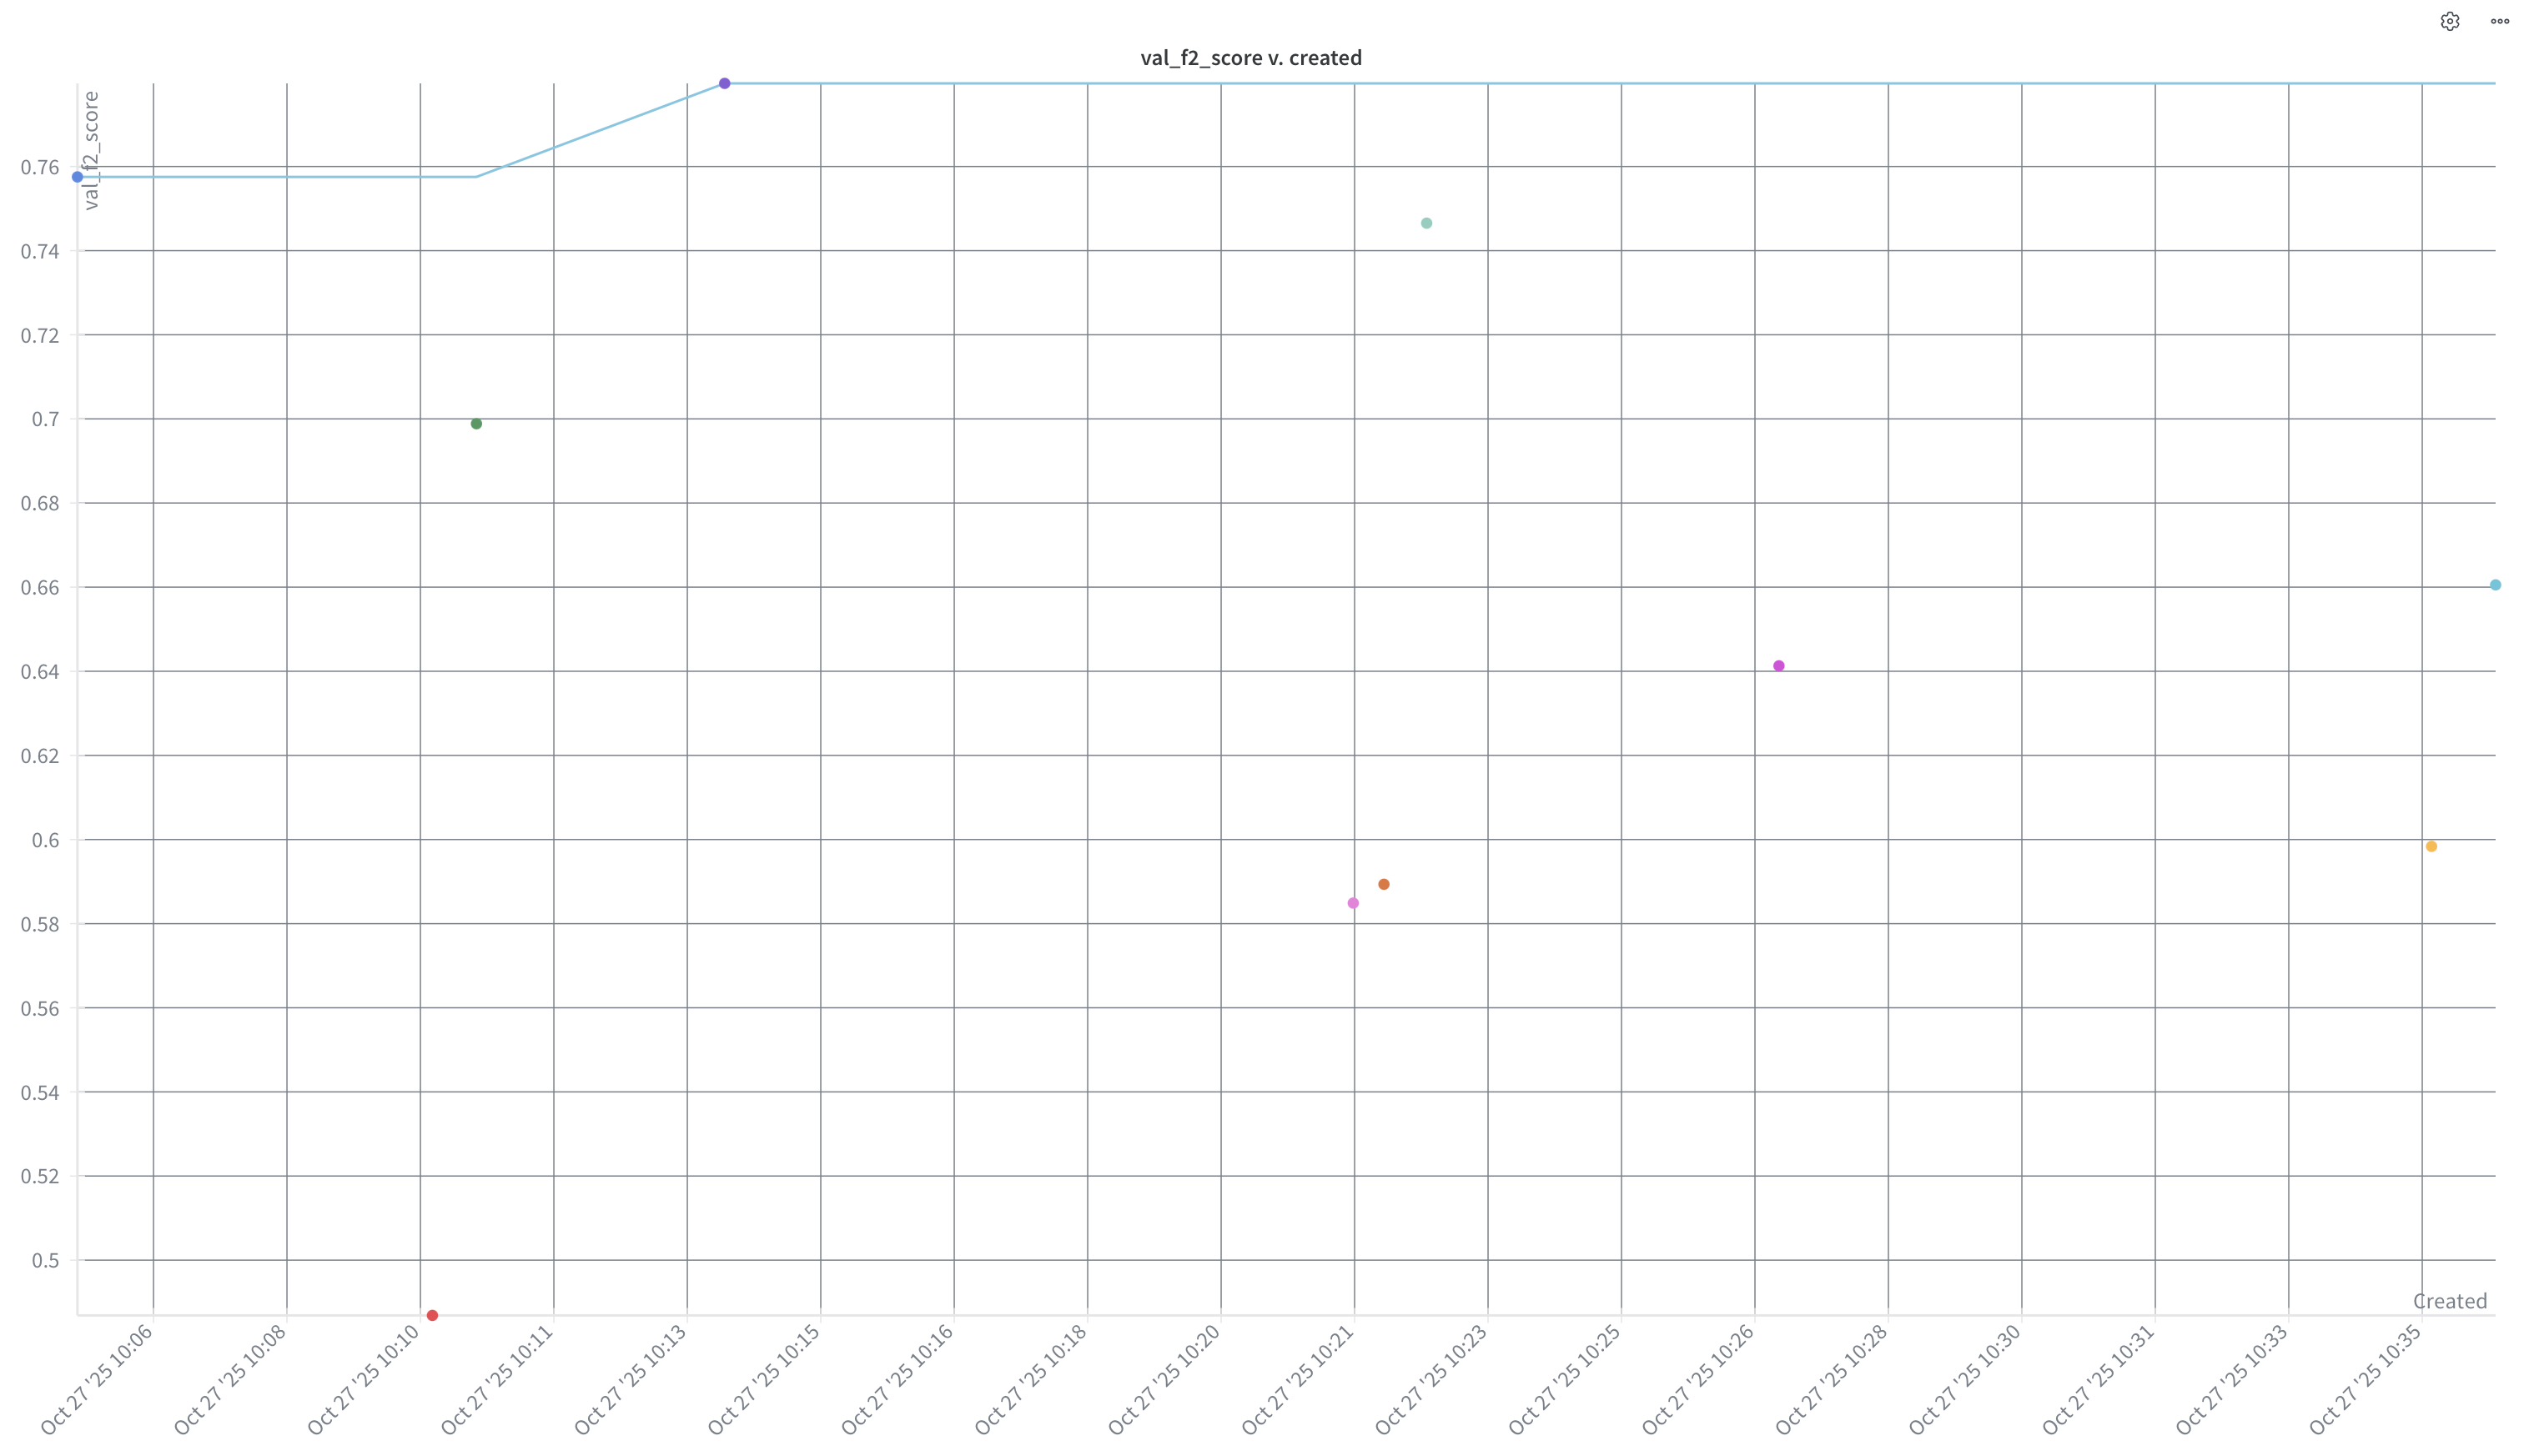

| Observation                                                                 | Interpretation                                                     |
|------------------------------------------------------------------------------|--------------------------------------------------------------------|
| Bayesian Optimization W&B Hyperparameter Sweep found optimum F2 Scores fast           | Efficiently identified high-performing settings early              |
| Curve plateaus at a high value (around 0.77)                                | Little improvement seen with additional runs                       |
| Some variability in later runs with lower scores                            | Sweep still explored suboptimal regions, but best was already found |



### Hyperparameter Importance Plot 
The purpose of the hyperparameter importance plot is to find most impactful hyperparameters, to not waste time and computational resources. Also I can understand **which direction** to expand search space for important hyperparameters 
- **High Positive Correlation:** Increasing hyperparameter tends to improve the score
- **High Negative Correlation**: Increasing hyperparameter will decrease score


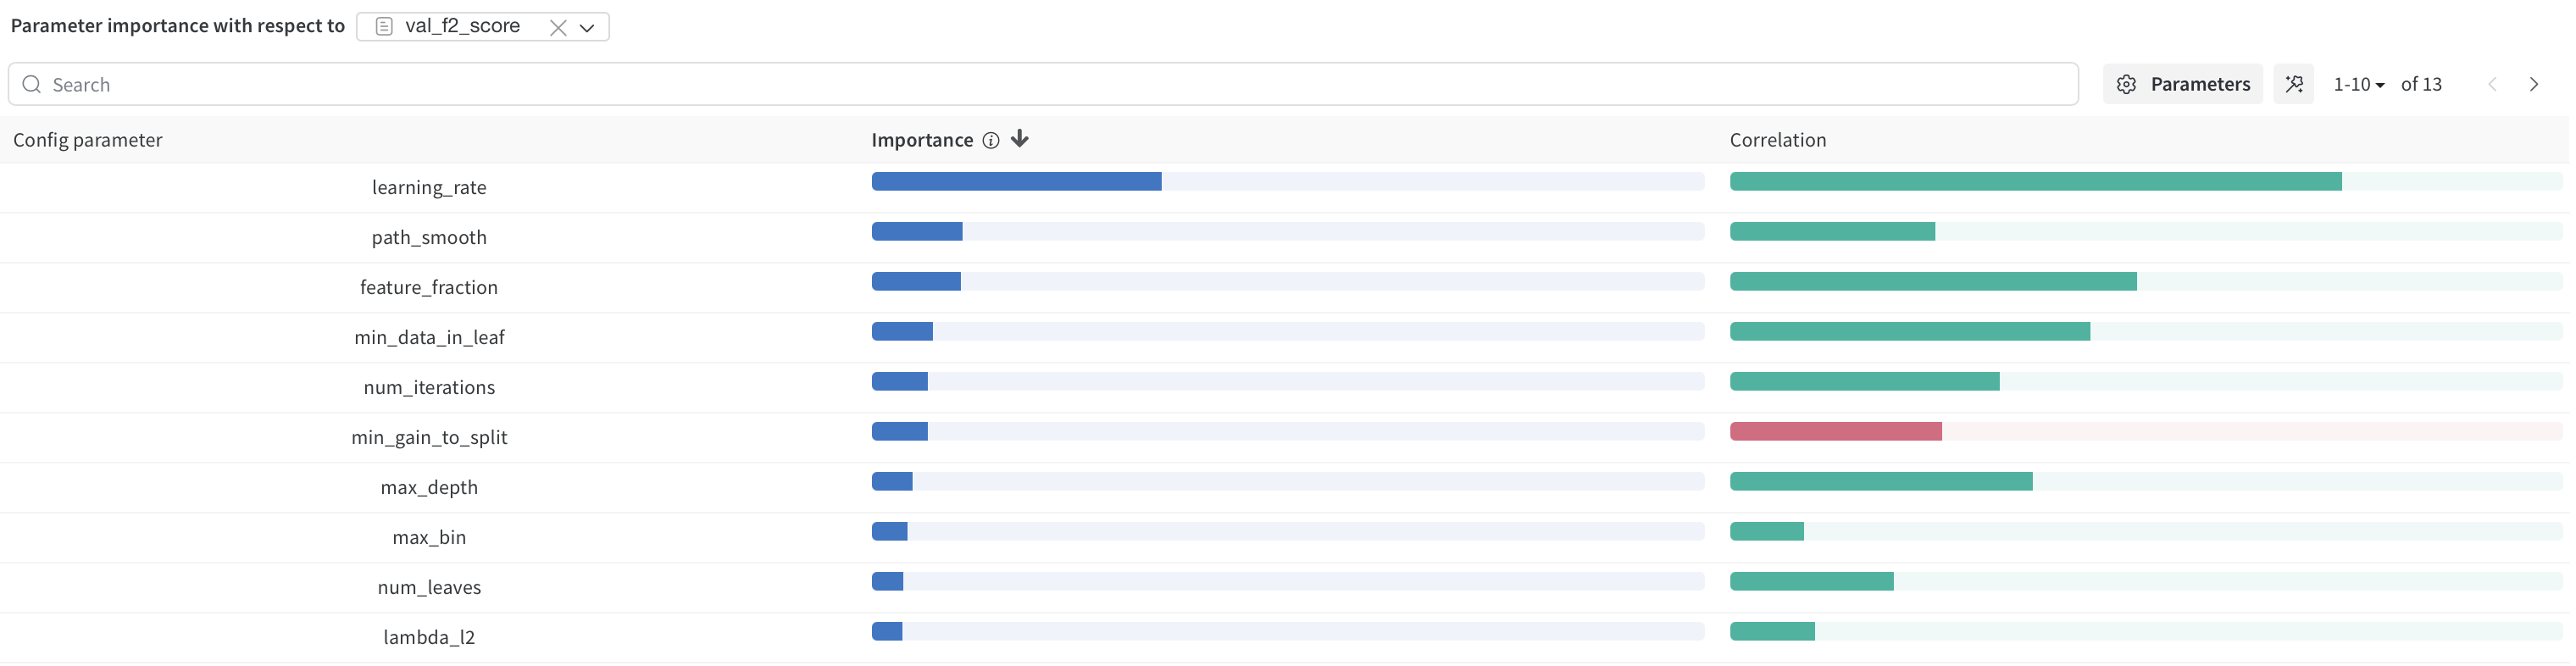



| **Key Finding** | **Actionable Step** |
| --- | --- |
| High positive correlation (important parameters) | Shift search boundary higher; explore larger values for improvement (e.g. `learning_rate`, `feature_fraction`, `min_data_in_leaf`)|
| High negative correlation (important parameters) | Shift search boundary lower; focus on smaller values in further sweeps (e.g. `min_gain_to_split`) |
| Low-importance hyperparameters | Ignore, or remove as I deem fit |


We shall not conduct further hyperparameter sweepings, since our results are extremely satisfactory already, i.e. F2 Score of 0.77 on Validation Folds on average after hyperparameter sweeping. 

### Parallel Coordinates Plot
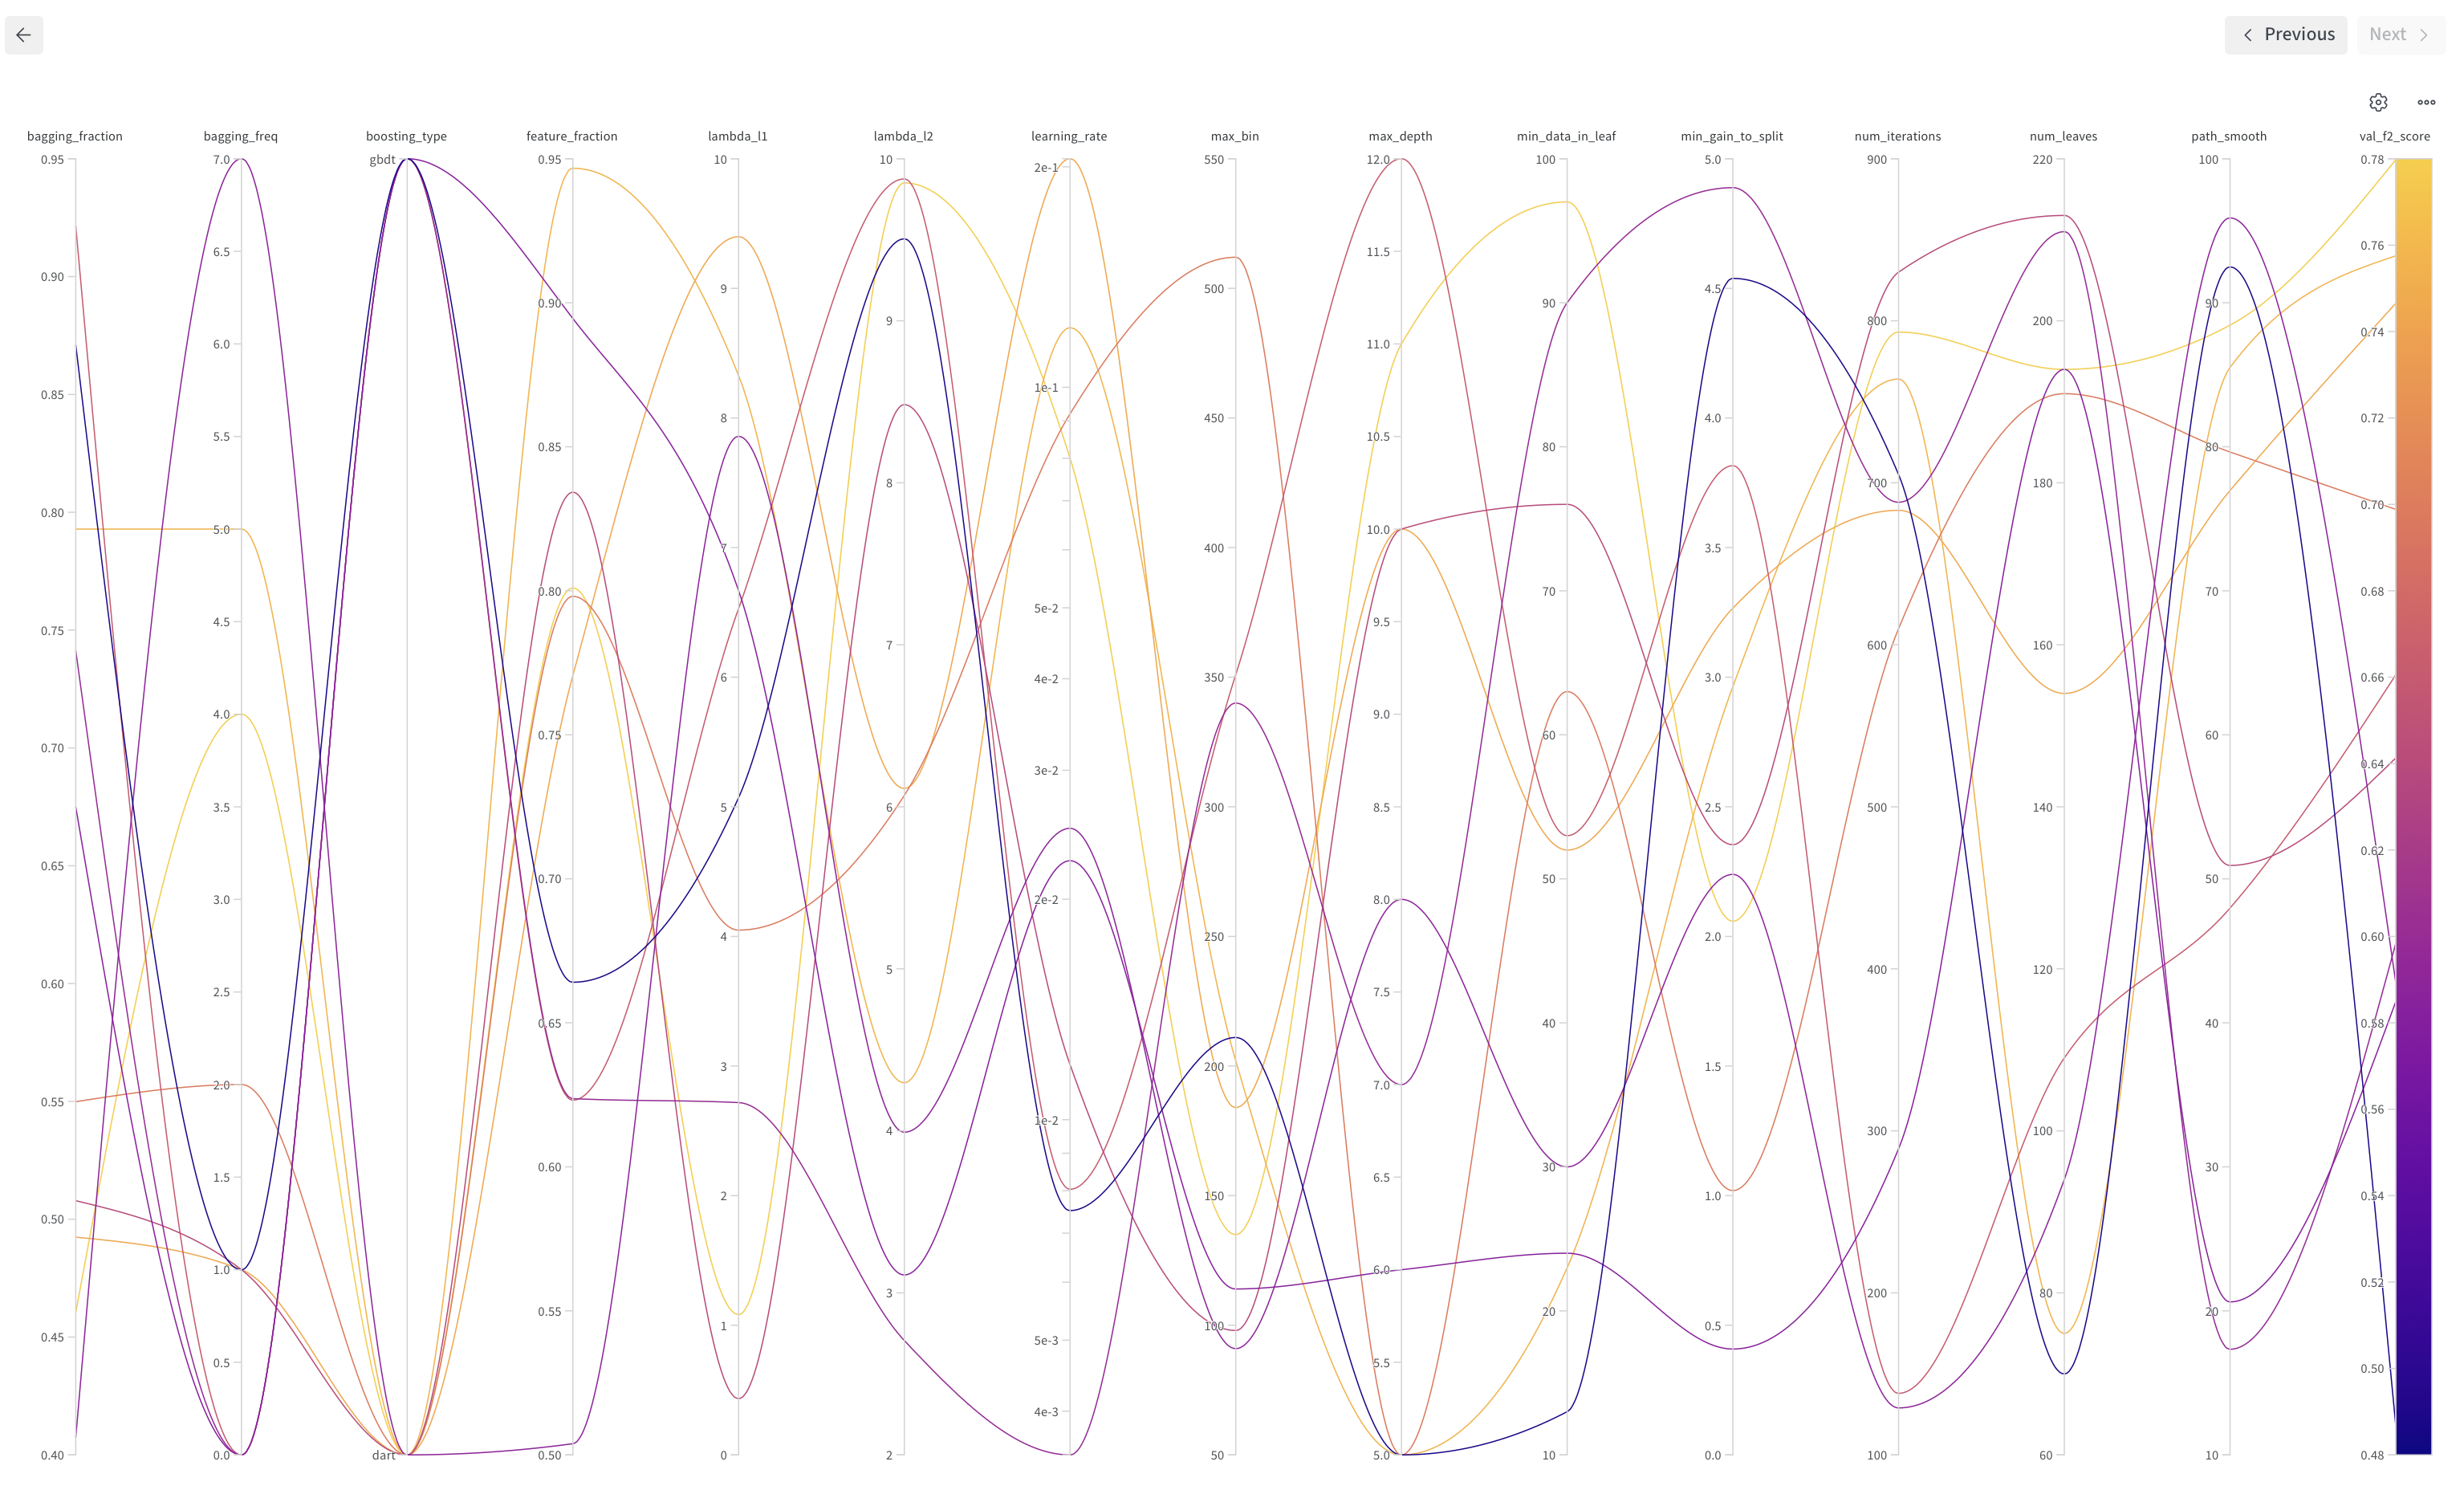

| Key Finding from Parallel Coordinates Plot                                         | Actionable Step                                                          |
|------------------------------------------------------------------------------------|--------------------------------------------------------------------------|
| Bright/high-performing lines cluster at particular parameter values                | Keep or further refine those parameter settings; they are likely optimal.(e.g. `gbdt`, `path_smooth` > 80, `feature_fraction` > 0.85, `min_data_in_leaf` > 90 etc)|
| Lines (bright or dark) converge at a value but performance is poor                 | Avoid or deprioritize those values; they do not yield good results.      |
| Parameters with strong positive correlation to performance (bright lines rise)      | Shift search boundary higher; focus on larger values for future sweeps.  |
| Parameters with strong negative correlation to performance (bright lines fall)      | Shift search boundary lower; focus on smaller values for future sweeps. (`min_gan_to_split` should have lower values) |
| Parameter shows scattered line patterns (no clustering; all performances mixed)     | Consider this parameter low-importance; use default or remove from sweep.|
| Overall sweep achieves high validation score (e.g., F2 ≈ 0.77)                     | No further sweeps needed; current parameter selection is successful.     |
          

## 8. Hyperparameter Sweep 2

In [18]:
sweep2_config = {'method': 'bayes',
 'metric': {'goal': 'maximize', 'name': 'val_f2_score'},
 'parameters': {'bagging_fraction': {'distribution': 'uniform',
                                     'max': 1.0,
                                     'min': 0.4},
                'bagging_freq': {'distribution': 'int_uniform',
                                 'max': 7,
                                 'min': 0},
                'boosting_type':  {'values': ['gbdt']},
                'feature_fraction': {'distribution': 'uniform',
                                     'max': 1.0,
                                     'min': 0.7},
                'lambda_l1': {'distribution': 'uniform',
                              'max': 10.0,
                              'min': 0.0},
                'lambda_l2': {'distribution': 'uniform',
                              'max': 10.0,
                              'min': 3.0},
                'learning_rate': {'distribution': 'log_uniform_values',
                                  'max': 0.3,
                                  'min': 0.01},
                'max_bin': {'distribution': 'int_uniform',
                            'max': 512,
                            'min': 63},
                'max_depth': {'distribution': 'int_uniform',
                              'max': 12,
                              'min': 3},
                'min_data_in_leaf': {'distribution': 'int_uniform',
                                     'max': 100,
                                     'min': 5},
                'min_gain_to_split': {'distribution': 'uniform',
                                      'max': 5.0,
                                      'min': 0.0},
                'num_iterations': {'distribution': 'int_uniform',
                                   'max': 1000,
                                   'min': 100},
                'num_leaves': {'distribution': 'int_uniform',
                               'max': 300,
                               'min': 10},
                'path_smooth': {'distribution': 'uniform',
                                'max': 100.0,
                                'min': 0.0}}}

In [19]:
sweep_id = wandb.sweep(sweep=sweep2_config, project="Fraud Detection")

Create sweep with ID: w08tylb5
Sweep URL: https://wandb.ai/wlunlun1212-singapore-management-university/Fraud%20Detection/sweeps/w08tylb5


In [20]:
wandb.agent(sweep_id=sweep_id, function=training_function, count=10)

Breaking out from seriousness a bit, isn't it so cool increasing lower bound of `feature_fraction` from 0.4 - 0.7 made the Validation F2 Score increase converge ~ 0.80? First, I identified that good scores often happen around `feature_fraction` of >= 0.75, as such I increased the lower bound of `feature_fraction` to 0.7. This was a contributing factor to increased validation F2 Score! This is reasonable in ML terminology too, since increasing `feature_fraction` often refer to number of input features used by each decision tree built by LightGBM. Just like a toolman with more tools to choose from, each decision tree can now choose the features that give the best partitioning of fraud vs non-fraud locally. This reduces overfitting to training data. 


| **Before** | **After** | 
|:-:|:-:|
| 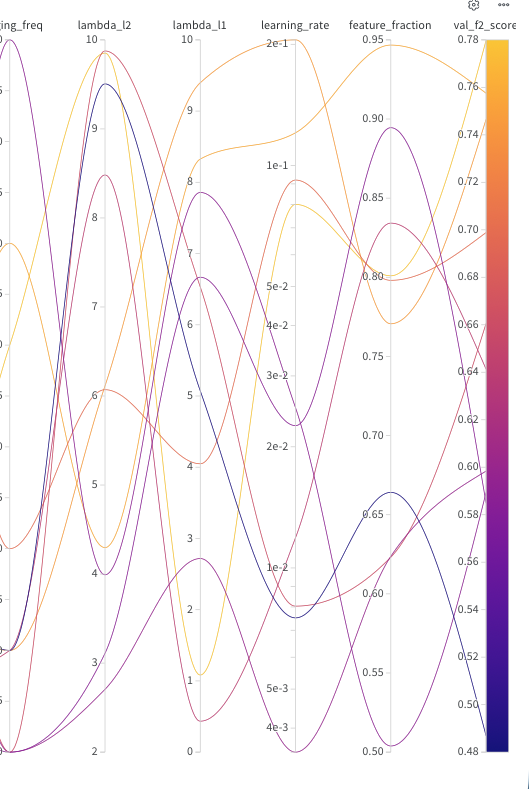 | 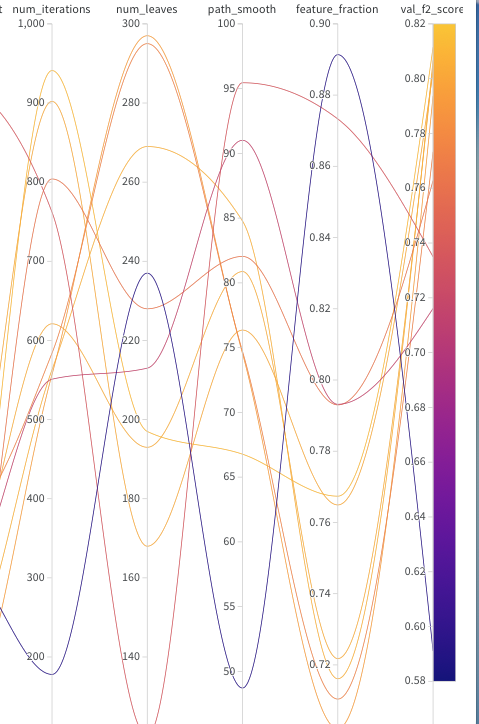 |



## 9. Best Sweep Hyperparameter Selection 

In [21]:

# print("Best run score:", best_run.summary['val_f2_score'])
best_hyperparams ={
  "max_bin": {
    "value": 507
  },
  "lambda_l1": {
    "value": 2.0424413666422714
  },
  "lambda_l2": {
    "value": 5.7898984238396975
  },
  "max_depth": {
    "value": 7
  },
  "num_leaves": {
    "value": 197
  },
  "path_smooth": {
    "value": 66.77125260881193
  },
  "bagging_freq": {
    "value": 6
  },
  "boosting_type": {
    "value": "gbdt"
  },
  "learning_rate": {
    "value": 0.03241365335883643
  },
  "num_iterations": {
    "value": 941
  },
  "bagging_fraction": {
    "value": 0.691743347603448
  },
  "feature_fraction": {
    "value": 0.7673819671101265
  },
  "min_data_in_leaf": {
    "value": 81
  },
  "min_gain_to_split": {
    "value": 0.5254136553377875
  }
}


## 7. Model Evaluation (Test Set)


### Train Final Model with Best Hyperparameters

In [22]:
# Extract best hyperparameters from the sweep results
best_params = {}
for param, config in best_hyperparams.items():
    best_params[param] = config['value']

# Add the base parameters that were constant during sweep
final_lightgbm_params = {
    'objective': 'binary',
    'random_state': 42,
    'n_jobs': -1,
    'device_type': 'cpu',
    'verbose': -1,
    'force_col_wise': True,
    **best_params  # Add the optimized hyperparameters
}

print("Final LightGBM Parameters:")
print("=" * 50)
for param, value in final_lightgbm_params.items():
    print(f"{param}: {value}")

# Create the final pipeline with optimized hyperparameters
final_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('lgbm', LGBMClassifier(**final_lightgbm_params))
])

print(f"\n✅ Created final pipeline with optimized hyperparameters")
print(f"✅ Expected validation F2 score: ~0.80 (based on sweep results)")

Final LightGBM Parameters:
objective: binary
random_state: 42
n_jobs: -1
device_type: cpu
verbose: -1
force_col_wise: True
max_bin: 507
lambda_l1: 2.0424413666422714
lambda_l2: 5.7898984238396975
max_depth: 7
num_leaves: 197
path_smooth: 66.77125260881193
bagging_freq: 6
boosting_type: gbdt
learning_rate: 0.03241365335883643
num_iterations: 941
bagging_fraction: 0.691743347603448
feature_fraction: 0.7673819671101265
min_data_in_leaf: 81
min_gain_to_split: 0.5254136553377875

✅ Created final pipeline with optimized hyperparameters
✅ Expected validation F2 score: ~0.80 (based on sweep results)


In [23]:
# Train the final model on the entire training set
print("Training final model on entire training set...")
print("=" * 50)

# Train the pipeline (SMOTE + LightGBM) on the full training data
final_pipeline.fit(X_train_scaled, y_train)

print("✅ Final model training completed!")
print(f"✅ Model trained on {len(X_train_scaled)} samples")
print(f"✅ SMOTE applied during training to handle class imbalance")

# Display the final model info
print(f"\nFinal Model Components:")
print(f"- SMOTE: {final_pipeline.named_steps['smote']}")
print(f"- LightGBM: {final_pipeline.named_steps['lgbm']}")
print(f"- Number of features: {final_pipeline.named_steps['lgbm'].n_features_in_}")
print(f"- Number of boosting rounds: {final_pipeline.named_steps['lgbm'].n_estimators}")

# Check class distribution after SMOTE (from the training process)
print(f"\nOriginal training class distribution:")
print(y_train.value_counts())
print("\nNote: SMOTE was applied internally during pipeline training")

Training final model on entire training set...
✅ Final model training completed!
✅ Model trained on 226980 samples
✅ SMOTE applied during training to handle class imbalance

Final Model Components:
- SMOTE: SMOTE(random_state=42)
- LightGBM: LGBMClassifier(bagging_fraction=0.691743347603448, bagging_freq=6,
               device_type='cpu', feature_fraction=0.7673819671101265,
               force_col_wise=True, lambda_l1=2.0424413666422714,
               lambda_l2=5.7898984238396975, learning_rate=0.03241365335883643,
               max_bin=507, max_depth=7, min_data_in_leaf=81,
               min_gain_to_split=0.5254136553377875, n_jobs=-1,
               num_iterations=941, num_leaves=197, objective='binary',
               path_smooth=66.77125260881193, random_state=42, verbose=-1)
- Number of features: 30
- Number of boosting rounds: 100

Original training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Note: SMOTE was applied internally during pipeli

### Test Set Evaluation

In [24]:
# Generate predictions on test set
print("Evaluating model on test set...")
print("=" * 40)

# Get predictions and probabilities
y_test_pred = final_pipeline.predict(X_test_scaled)
y_test_pred_proba = final_pipeline.predict_proba(X_test_scaled)[:, 1]

# Calculate comprehensive metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    precision_recall_curve, roc_curve, auc
)

# Basic metrics
test_f2_score = fbeta_score(y_test, y_test_pred, beta=2)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1_score = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)
test_pr_auc = average_precision_score(y_test, y_test_pred_proba)

print("TEST SET PERFORMANCE METRICS")
print("=" * 40)
print(f"F2 Score:        {test_f2_score:.4f}")
print(f"Precision:       {test_precision:.4f}")
print(f"Recall:          {test_recall:.4f}")
print(f"F1 Score:        {test_f1_score:.4f}")
print(f"ROC AUC:         {test_roc_auc:.4f}")
print(f"PR AUC:          {test_pr_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\nCONFUSION MATRIX")
print("=" * 25)
print(f"True Negatives:  {cm[0,0]:,}")
print(f"False Positives: {cm[0,1]:,}")
print(f"False Negatives: {cm[1,0]:,}")
print(f"True Positives:  {cm[1,1]:,}")

# Calculate additional fraud detection specific metrics
total_fraud_cases = cm[1,0] + cm[1,1]  # FN + TP
detected_fraud_cases = cm[1,1]  # TP
fraud_detection_rate = detected_fraud_cases / total_fraud_cases if total_fraud_cases > 0 else 0

total_predictions = cm.sum()
false_alarm_rate = cm[0,1] / total_predictions  # FP rate relative to all predictions

print(f"\nFRAUD DETECTION SPECIFIC METRICS")
print("=" * 40)
print(f"Total fraud cases in test:       {total_fraud_cases:,}")
print(f"Fraud cases detected:            {detected_fraud_cases:,}")
print(f"Fraud detection rate:           {fraud_detection_rate:.4f} ({fraud_detection_rate*100:.2f}%)")
print(f"False alarm rate:               {false_alarm_rate:.4f} ({false_alarm_rate*100:.2f}%)")

print(f"\n✅ Model successfully evaluated on {len(X_test_scaled):,} test samples")
print(f"✅ Test set contains {(y_test==1).sum():,} fraud cases and {(y_test==0).sum():,} normal cases")

Evaluating model on test set...
TEST SET PERFORMANCE METRICS
F2 Score:        0.7771
Precision:       0.6972
Recall:          0.8000
F1 Score:        0.7451
ROC AUC:         0.9770
PR AUC:          0.8173

CONFUSION MATRIX
True Negatives:  56,618
False Positives: 33
False Negatives: 19
True Positives:  76

FRAUD DETECTION SPECIFIC METRICS
Total fraud cases in test:       95
Fraud cases detected:            76
Fraud detection rate:           0.8000 (80.00%)
False alarm rate:               0.0006 (0.06%)

✅ Model successfully evaluated on 56,746 test samples
✅ Test set contains 95 fraud cases and 56,651 normal cases
TEST SET PERFORMANCE METRICS
F2 Score:        0.7771
Precision:       0.6972
Recall:          0.8000
F1 Score:        0.7451
ROC AUC:         0.9770
PR AUC:          0.8173

CONFUSION MATRIX
True Negatives:  56,618
False Positives: 33
False Negatives: 19
True Positives:  76

FRAUD DETECTION SPECIFIC METRICS
Total fraud cases in test:       95
Fraud cases detected:            

In [25]:
# Detailed classification report
print("\nDETAILED CLASSIFICATION REPORT")
print("=" * 50)
class_names = ['Non-Fraud', 'Fraud']
report = classification_report(y_test, y_test_pred, target_names=class_names, digits=4)
print(report)

# Feature importance from the final model
print("\nTOP 10 MOST IMPORTANT FEATURES")
print("=" * 40)
feature_importance = final_pipeline.named_steps['lgbm'].feature_importances_
feature_names = X_train_scaled.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

for i, (idx, row) in enumerate(importance_df.head(10).iterrows()):
    print(f"{i+1:2d}. {row['feature']:15s}: {row['importance']:8.0f}")

print(f"\n✅ Feature importance calculated from {len(feature_names)} features")


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Non-Fraud     0.9997    0.9994    0.9995     56651
       Fraud     0.6972    0.8000    0.7451        95

    accuracy                         0.9991     56746
   macro avg     0.8485    0.8997    0.8723     56746
weighted avg     0.9992    0.9991    0.9991     56746


TOP 10 MOST IMPORTANT FEATURES
 1. V14            :     1681
 2. V4             :     1601
 3. Amount         :     1433
 4. V1             :     1219
 5. V12            :     1196
 6. V26            :     1079
 7. V11            :     1058
 8. V24            :     1025
 9. V20            :     1024
10. V7             :     1024

✅ Feature importance calculated from 30 features


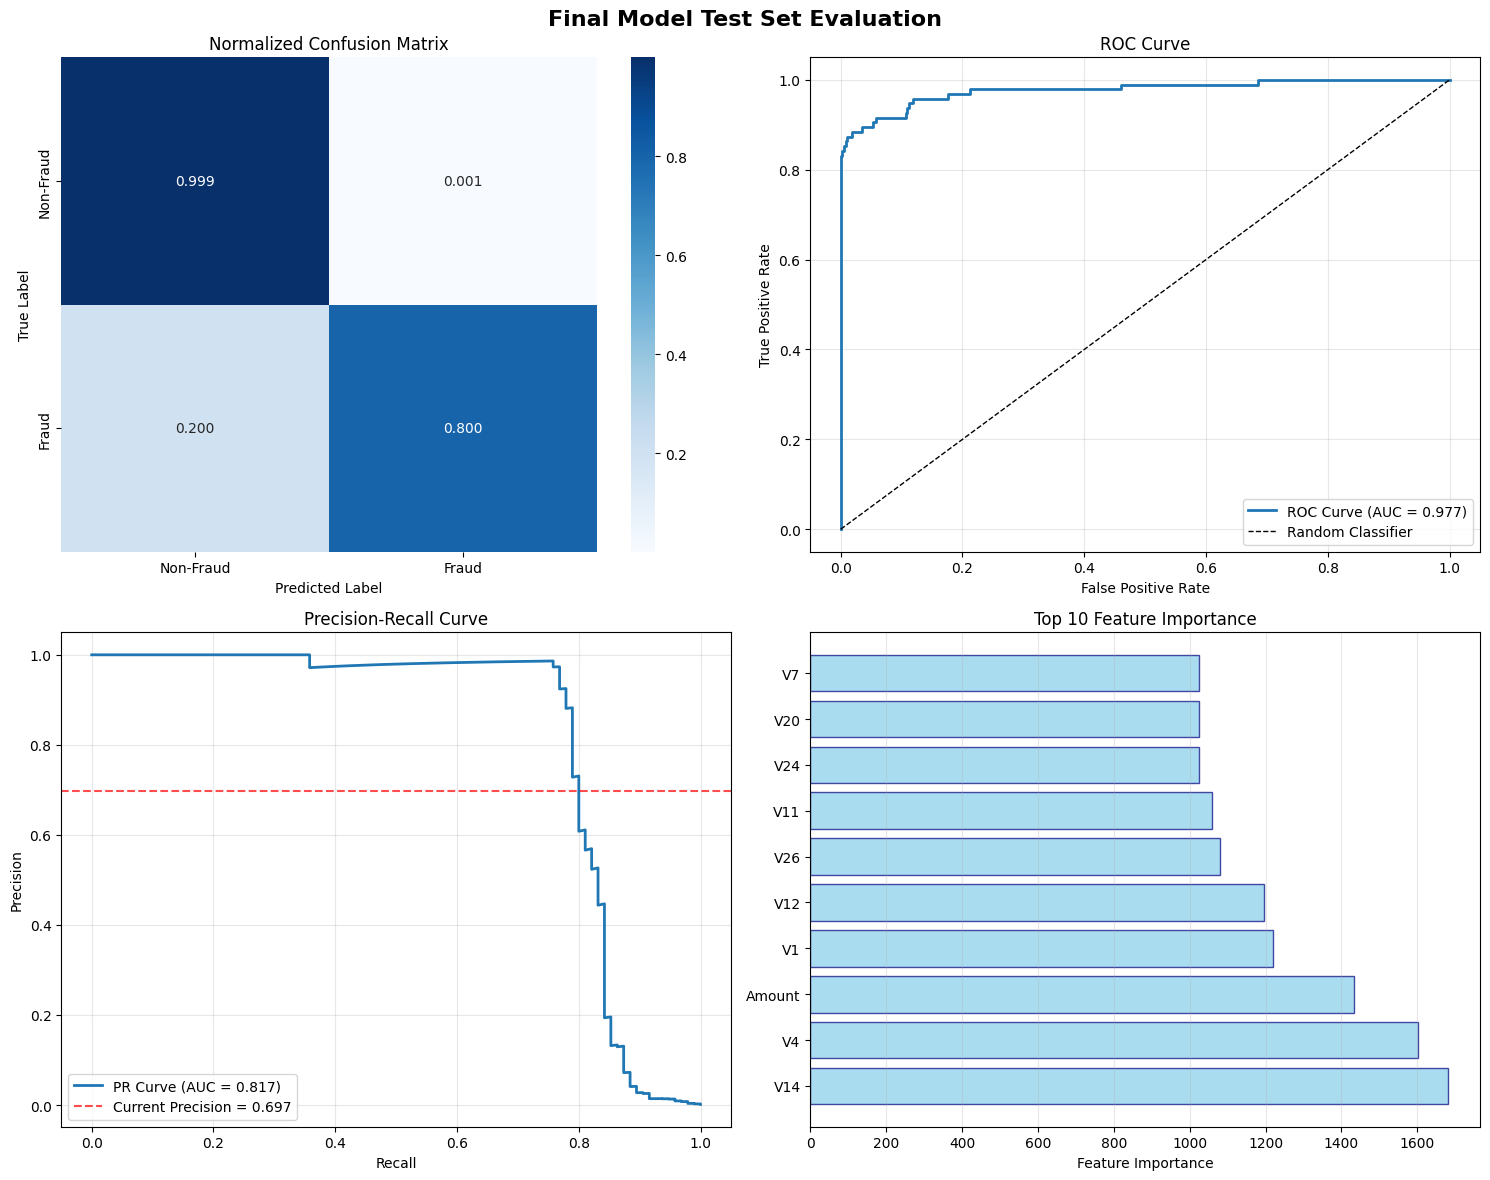

Test set evaluation visualizations created successfully!


In [26]:
# Create visualizations for test set evaluation
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Final Model Test Set Evaluation', fontsize=16, fontweight='bold')

# 1. Confusion Matrix Heatmap
cm_normalized = confusion_matrix(y_test, y_test_pred, normalize='true')
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0,0])
axes[0,0].set_title('Normalized Confusion Matrix')
axes[0,0].set_ylabel('True Label')
axes[0,0].set_xlabel('Predicted Label')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
axes[0,1].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {test_roc_auc:.3f})')
axes[0,1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_pred_proba)
axes[1,0].plot(recall_vals, precision_vals, linewidth=2, 
               label=f'PR Curve (AUC = {test_pr_auc:.3f})')
axes[1,0].axhline(y=test_precision, color='red', linestyle='--', alpha=0.7,
                  label=f'Current Precision = {test_precision:.3f}')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Feature Importance (Top 10)
top_10_features = importance_df.head(10)
axes[1,1].barh(range(len(top_10_features)), top_10_features['importance'], 
               color='skyblue', edgecolor='navy', alpha=0.7)
axes[1,1].set_yticks(range(len(top_10_features)))
axes[1,1].set_yticklabels(top_10_features['feature'], fontsize=10)
axes[1,1].set_xlabel('Feature Importance')
axes[1,1].set_title('Top 10 Feature Importance')
axes[1,1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("Test set evaluation visualizations created successfully!")

In [27]:
# Log test set evaluation to WandB
run = wandb.init(
    project="Fraud Detection",
    name="final_model_test_evaluation",
    job_type="test_evaluation",
    tags=[ "test_eval"],
    config={
        **final_lightgbm_params,
        "pipeline": "SMOTE + LightGBM (Optimized)",
        "test_samples": len(X_test_scaled),
        "train_samples": len(X_train_scaled),
        "features": len(X_train_scaled.columns)
    },
    settings=wandb.Settings(_disable_stats=True, _disable_meta=True)
)

# Log test metrics
wandb.log({
    "test_f2_score": test_f2_score,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1_score": test_f1_score,
    "test_roc_auc": test_roc_auc,
    "test_pr_auc": test_pr_auc,
    "fraud_detection_rate": fraud_detection_rate,
    "false_alarm_rate": false_alarm_rate,
    "total_fraud_cases": total_fraud_cases,
    "detected_fraud_cases": detected_fraud_cases
})

# Log confusion matrix and curves
wandb.log({
    "test_confusion_matrix": wandb.plot.confusion_matrix(
        probs=final_pipeline.predict_proba(X_test_scaled), 
        y_true=y_test.to_numpy(), 
        class_names=['Non-Fraud', 'Fraud']
    ),
    "test_roc_curve": wandb.plot.roc_curve(y_test, final_pipeline.predict_proba(X_test_scaled)),
    "test_pr_curve": wandb.plot.pr_curve(y_test, final_pipeline.predict_proba(X_test_scaled))
})

# Log feature importance table
feature_importance_table = wandb.Table(
    columns=["Feature", "Importance"],
    data=[[row['feature'], row['importance']] for _, row in importance_df.iterrows()]
)
wandb.log({"feature_importance": feature_importance_table})

# Log classification report as table
report_dict = classification_report(y_test, y_test_pred, target_names=class_names, output_dict=True)
classification_table = wandb.Table(
    columns=["Class", "Precision", "Recall", "F1-Score", "Support"],
    data=[
        ["Non-Fraud", report_dict['Non-Fraud']['precision'], report_dict['Non-Fraud']['recall'], 
         report_dict['Non-Fraud']['f1-score'], report_dict['Non-Fraud']['support']],
        ["Fraud", report_dict['Fraud']['precision'], report_dict['Fraud']['recall'], 
         report_dict['Fraud']['f1-score'], report_dict['Fraud']['support']]
    ]
)
wandb.log({"classification_report": classification_table})

run.finish()

# Compare with baseline model performance
print("PERFORMANCE COMPARISON")
print("=" * 30)
print("Validation (CV) vs Test Set Performance:")
print(f"Expected F2 (from CV):  ~0.80")
print(f"Actual F2 (test set):   {test_f2_score:.4f}")

performance_gap = abs(0.80 - test_f2_score)
if performance_gap < 0.05:
    print(f"✅ Performance gap: {performance_gap:.4f} - Model generalizes well!")
elif performance_gap < 0.10:
    print(f"Performance gap: {performance_gap:.4f} - Slight overfitting detected")
else:
    print(f"Performance gap: {performance_gap:.4f} - Significant overfitting!")

# Final model summary
print(f"\nFINAL MODEL SUMMARY")
print("=" * 25)
print(f"Architecture:     SMOTE + LightGBM")
print(f"Training samples: {len(X_train_scaled):,}")
print(f"Test samples:     {len(X_test_scaled):,}")
print(f"Features:         {len(X_train_scaled.columns)}")
print(f"Best F2 Score:    {test_f2_score:.4f}")
print(f"Fraud Detection:  {fraud_detection_rate*100:.1f}% of fraud cases caught")
print(f"False Alarms:     {false_alarm_rate*100:.2f}% of all predictions")

print(f"\n✅ MODEL READY FOR PRODUCTION DEPLOYMENT!")
print(f"✅ Test evaluation logged to WandB successfully!")

PERFORMANCE COMPARISON
Validation (CV) vs Test Set Performance:
Expected F2 (from CV):  ~0.80
Actual F2 (test set):   0.7771
✅ Performance gap: 0.0229 - Model generalizes well!

FINAL MODEL SUMMARY
Architecture:     SMOTE + LightGBM
Training samples: 226,980
Test samples:     56,746
Features:         30
Best F2 Score:    0.7771
Fraud Detection:  80.0% of fraud cases caught
False Alarms:     0.06% of all predictions

✅ MODEL READY FOR PRODUCTION DEPLOYMENT!
✅ Test evaluation logged to WandB successfully!


In [ ]:
# Model Saving
import joblib
joblib.dump(final_pipeline, 'models/lightgbm.pkl')

['models/lightgbm.pkl']